# Разведывательный анализ данных о загрязнении воздуха в городах Индии

Федоров Иван 332 группа
Ссылка на датасет: https://www.kaggle.com/datasets/bhautikvekariya21/air-quality-dataset-indian-cities-2022-2025/data
Здесь будет выполняться разведывательный анализ данных: мы изучаем структуру таблицы, проверяем пропуски и дубликаты, смотрим распределения, выбросы, сезонность и корреляции.

После этого EDA можно переходить к основной части проекта — построению моделей машинного обучения.

Для этого датасета лучше всего подходят следующие задачи:

1. **Регрессия** — предсказание числового значения `US_AQI`.
2. **Классификация** — предсказание категории качества воздуха `AQI_Category`.

Основной задачей проекта логично выбрать **регрессию** или **классификацию**, потому что в датасете уже есть понятные целевые переменные: `US_AQI` и `AQI_Category`.  
Кластеризацию можно добавить как дополнительный аналитический блок.

## Краткое описание признаков

Датасет содержит почасовые наблюдения о качестве воздуха в городах Индии за 2022–2025 годы.  
Одна строка — это наблюдение в конкретном городе в конкретный момент времени.

В данных есть несколько групп признаков:

### Географические признаки

- `City` — город;
- `State` — штат;
- `Latitude`, `Longitude` — координаты.

Эти признаки позволяют сравнивать качество воздуха между городами и регионами.

### Временные признаки

- `Datetime` — дата и время наблюдения;
- `Year`, `Month`, `Day`, `Hour` — год, месяц, день и час;
- `Day_of_Week`, `Is_Weekend`, `Quarter` — календарные признаки;
- `Season`, `Time_of_Day` — сезон и время суток.

Эти признаки нужны для анализа сезонности и суточных изменений загрязнения.

### Признаки загрязнения воздуха

- `PM2_5_ugm3`, `PM10_ugm3` — концентрации взвешенных частиц;
- `CO_ugm3`, `NO2_ugm3`, `SO2_ugm3`, `O3_ugm3` — концентрации газообразных загрязнителей;
- `Dust_ugm3`, `AOD` — дополнительные показатели загрязнения;
- `US_AQI`, `EU_AQI` — индексы качества воздуха.

Эти признаки напрямую связаны с уровнем загрязнения.

### Погодные признаки

- `Temp_2m_C` — температура;
- `Humidity_Percent` — влажность;
- `Wind_Speed_10m_kmh`, `Wind_Gusts_kmh` — скорость ветра и порывы;
- `Precipitation_mm`, `Rain_mm` — осадки;
- `Pressure_MSL_hPa` — атмосферное давление;
- `Cloud_Cover_Percent` — облачность;
- `Solar_Radiation_Wm2` — солнечная радиация.

Погода может влиять на накопление или рассеивание загрязнителей.

### Целевые переменные для будущей части проекта

- `US_AQI` — числовая целевая переменная для регрессии;
- `AQI_Category` — категориальная целевая переменная для классификации.

## Цели EDA

В этом ноутбуке мы:

1. изучим структуру датасета;
2. проверим пропуски и дубликаты;
3. удалим полностью пустые признаки;
4. обработаем оставшиеся пропуски;
5. посмотрим распределение `US_AQI`;
6. посмотрим распределение `AQI_Category`;
7. проанализируем выбросы;
8. сравним качество воздуха по городам, сезонам, месяцам и часам;
9. изучим корреляции важных признаков;
10. сохраним очищенный датасет для дальнейшего моделирования.

## Что будем делать с выбросами

В данных о загрязнении воздуха выбросы не всегда являются ошибками.  
Очень высокие значения `PM2_5_ugm3`, `PM10_ugm3` или `US_AQI` могут соответствовать реальным периодам сильного загрязнения, смога или неблагоприятной погоды.

Поэтому в EDA мы:

- найдём выбросы с помощью boxplot и метода IQR;
- оценим, в каких признаках выбросов больше всего;
- **не будем удалять выбросы автоматически**.

Это важно, потому что экстремальные наблюдения могут быть значимыми для анализа плохого качества воздуха.

## 1. Импорт библиотек

Подключим основные библиотеки для работы с данными и графиками.

In [228]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [229]:
# Дополнительные библиотеки для регрессии, классификации и кластеризации
# Импорты вынесены в начало проекта.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42


## 2. Загрузка данных

Загружаем исходный файл.

In [230]:
path = "INDIA_AQI_COMPLETE_20251126.csv"

df = pd.read_csv(path)

print("Размер исходного датасета:", df.shape)
df.head()

Размер исходного датасета: (842160, 71)


,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,Day_Name,Week_of_Year,Is_Weekend,Quarter,Season,Time_of_Day,Temp_2m_C,Temp_80m_C,Temp_120m_C,Temp_180m_C,Humidity_Percent,Dew_Point_C,Humidity_Category,Wind_Speed_10m_kmh,Wind_Speed_80m_kmh,Wind_Speed_120m_kmh,Wind_Dir_10m,Wind_Gusts_kmh,Wind_Category,Wind_Stagnation,Precipitation_mm,Rain_mm,Is_Raining,Heavy_Rain,Pressure_MSL_hPa,Surface_Pressure_hPa,Solar_Radiation_Wm2,Direct_Radiation_Wm2,Diffuse_Radiation_Wm2,UV_Index,Cloud_Cover_Percent,Cloud_Low_Percent,Cloud_Mid_Percent,Cloud_High_Percent,Is_Daytime,Sunshine_Seconds,PM2_5_ugm3,PM10_ugm3,PM_Ratio,CO_ugm3,NO2_ugm3,SO2_ugm3,O3_ugm3,Dust_ugm3,NH3_ugm3,AOD,US_AQI,US_AQI_PM25,US_AQI_PM10,US_AQI_NO2,US_AQI_O3,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Inversion_Strength_C,Festival_Period,Crop_Burning_Season
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,Friday,31,0,3,Monsoon,Night,26.7,NaN,NaN,NaN,91,25.1,Very_Humid,5.4,NaN,NaN,172,11.2,Moderate,0,0.0,0.0,0,0,1004.4,1003.0,0.0,0.0,0.0,NaN,100,0,7,100,0,0.0,14.8,21.5,0.688372,197.0,21.8,2.7,32.0,0.0,NaN,0.14,NaN,NaN,NaN,11.0,16.0,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,Friday,31,0,3,Monsoon,Night,26.4,NaN,NaN,NaN,93,25.2,Very_Humid,4.5,NaN,NaN,166,9.0,Light,0,0.0,0.0,0,0,1003.9,1002.5,0.0,0.0,0.0,NaN,100,3,4,100,0,0.0,15.7,22.8,0.688596,196.0,18.5,3.0,33.0,0.0,NaN,0.14,NaN,NaN,NaN,9.0,14.0,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,Friday,31,0,3,Monsoon,Night,26.1,NaN,NaN,NaN,95,25.2,Very_Humid,3.8,NaN,NaN,163,7.6,Light,0,0.0,0.0,0,0,1003.5,1002.1,0.0,0.0,0.0,NaN,100,2,2,100,0,0.0,16.3,23.5,0.693617,196.0,15.1,3.3,34.0,0.0,NaN,0.15,NaN,NaN,NaN,7.0,14.0,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,Friday,31,0,3,Monsoon,Night,26.0,NaN,NaN,NaN,96,25.2,Very_Humid,3.7,NaN,NaN,151,6.8,Light,0,0.0,0.0,0,0,1003.0,1001.6,0.0,0.0,0.0,NaN,100,0,1,100,0,0.0,17.6,25.4,0.692913,197.0,14.1,3.3,32.0,0.0,NaN,0.15,NaN,NaN,NaN,7.0,14.0,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,Friday,31,0,3,Monsoon,Night,25.8,NaN,NaN,NaN,97,25.2,Very_Humid,4.1,NaN,NaN,128,6.8,Light,0,0.0,0.0,0,0,1002.9,1001.5,0.0,0.0,0.0,NaN,100,0,1,100,0,0.0,18.2,26.2,0.694656,199.0,13.9,3.2,30.0,0.0,NaN,0.14,NaN,NaN,NaN,7.0,14.0,2,NaN,NaN,NaN,NaN,Good,0,NaN,0,0


Посмотрим типы признаков и количество непустых значений.

In [231]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Data columns (total 71 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   City                   842160 non-null  str    
 1   State                  842160 non-null  str    
 2   Latitude               842160 non-null  float64
 3   Longitude              842160 non-null  float64
 4   Datetime               842160 non-null  str    
 5   Year                   842160 non-null  int64  
 6   Month                  842160 non-null  int64  
 7   Day                    842160 non-null  int64  
 8   Hour                   842160 non-null  int64  
 9   Day_of_Week            842160 non-null  int64  
 10  Day_Name               842160 non-null  str    
 11  Week_of_Year           842160 non-null  int64  
 12  Is_Weekend             842160 non-null  int64  
 13  Quarter                842160 non-null  int64  
 14  Season                 842160 non-null  str    

Посмотрим описательные статистики по числовым признакам.

In [232]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,842160.0,23.129041,5.543478,8.524100,20.296100,23.831500,26.912400,31.10480
Longitude,842160.0,82.769207,6.937205,72.571400,77.173400,80.946200,88.606500,94.10860
Year,842160.0,2023.724793,0.995593,2022.000000,2023.000000,2024.000000,2025.000000,2025.00000
Month,842160.0,6.801653,3.411504,1.000000,4.000000,7.000000,10.000000,12.00000
Day,842160.0,15.736364,8.767003,1.000000,8.000000,16.000000,23.000000,31.00000
Hour,842160.0,11.500000,6.922191,0.000000,5.750000,11.500000,17.250000,23.00000
Day_of_Week,842160.0,3.000000,2.000827,0.000000,1.000000,3.000000,5.000000,6.00000
Week_of_Year,842160.0,27.767769,14.848660,1.000000,15.000000,29.000000,41.000000,52.00000
Is_Weekend,842160.0,0.285950,0.451866,0.000000,0.000000,0.000000,1.000000,1.00000
Quarter,842160.0,2.601653,1.112661,1.000000,2.000000,3.000000,4.000000,4.00000


**Вывод.**  
В датасете много строк и признаков, поэтому он подходит для полноценного EDA и последующего моделирования.  
По описательным статистикам видно, что значения загрязнителей и `US_AQI` имеют широкий диапазон: это означает, что в данных есть как периоды чистого воздуха, так и периоды сильного загрязнения.

In [233]:
print("Количество строк:", df.shape[0])
print("Количество колонок:", df.shape[1])
print("Количество дубликатов:", df.duplicated().sum())

print("\nКоличество городов:", df["City"].nunique())
print("Количество штатов:", df["State"].nunique())

print("\nПериод наблюдений:")
print("Минимальная дата:", df["Datetime"].min())
print("Максимальная дата:", df["Datetime"].max())

Количество строк: 842160
Количество колонок: 71
Количество дубликатов: 0

Количество городов: 29
Количество штатов: 29

Период наблюдений:
Минимальная дата: 2022-08-05 00:00:00
Максимальная дата: 2025-11-26 23:00:00


Преобразуем дату в формат `datetime` и отсортируем наблюдения по городу и времени.

In [234]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values(["City", "Datetime"]).reset_index(drop=True)

print("Минимальная дата:", df["Datetime"].min())
print("Максимальная дата:", df["Datetime"].max())

Минимальная дата: 2022-08-05 00:00:00
Максимальная дата: 2025-11-26 23:00:00


Проверим, сколько наблюдений приходится на каждый город.

In [235]:
city_counts = df["City"].value_counts()
city_counts

City
Agartala              29040
Ahmedabad             29040
Aizawl                29040
Bengaluru             29040
Bhopal                29040
Bhubaneswar           29040
Chandigarh            29040
Chennai               29040
Dehradun              29040
Delhi                 29040
Gangtok               29040
Gurugram              29040
Guwahati              29040
Hyderabad             29040
Imphal                29040
Itanagar              29040
Jaipur                29040
Kohima                29040
Kolkata               29040
Lucknow               29040
Mumbai                29040
Panaji                29040
Patna                 29040
Raipur                29040
Ranchi                29040
Shillong              29040
Shimla                29040
Thiruvananthapuram    29040
Visakhapatnam         29040
Name: count, dtype: int64

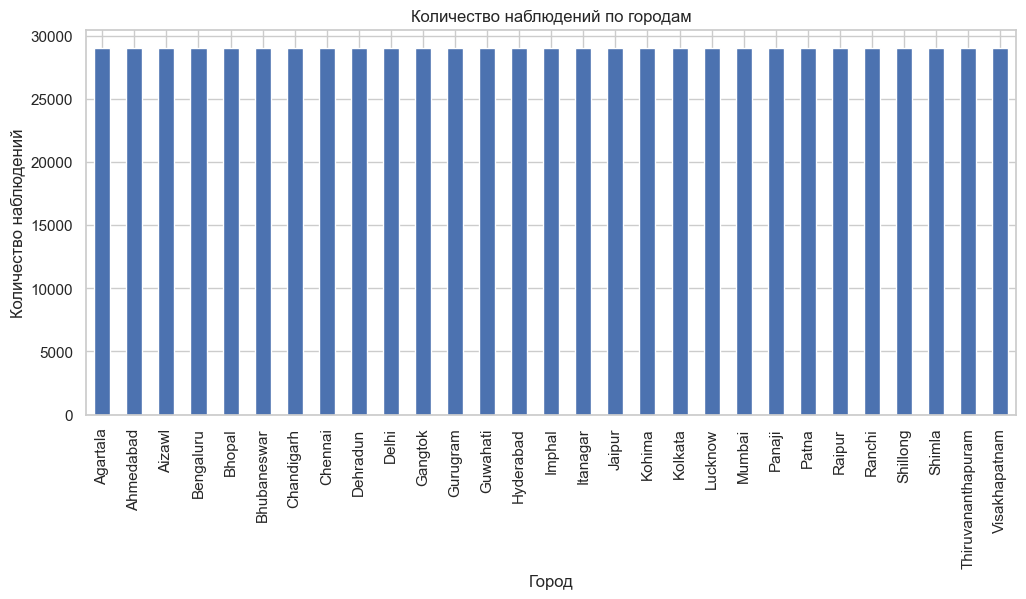

In [236]:
plt.figure(figsize=(12, 5))
city_counts.plot(kind="bar")
plt.title("Количество наблюдений по городам")
plt.xlabel("Город")
plt.ylabel("Количество наблюдений")
plt.xticks(rotation=90)
plt.show()

  
Количество наблюдений по городам примерно одинаковое, города представлены достаточно равномерно. Это важно для дальнейшего сравнения городов между собой.

In [237]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing[missing["missing_count"] > 0]

,missing_count,missing_percent
NH3_ugm3,842160,100.000000
Inversion_Strength_C,842160,100.000000
Wind_Speed_120m_kmh,842160,100.000000
Wind_Speed_80m_kmh,842160,100.000000
Temp_120m_C,842160,100.000000
Temp_180m_C,842160,100.000000
Temp_80m_C,842160,100.000000
UV_Index,842160,100.000000
AQI_Category,2516,0.298756
US_AQI,145,0.017218


Удалим признаки, которые полностью состоят из пропусков. Такие колонки не содержат полезной информации.

In [238]:
empty_cols = missing[missing["missing_percent"] == 100].index.tolist()

print("Полностью пустые колонки:")
print(empty_cols)

df = df.drop(columns=empty_cols)

print("\nРазмер после удаления пустых колонок:", df.shape)

Полностью пустые колонки:
['NH3_ugm3', 'Inversion_Strength_C', 'Wind_Speed_120m_kmh', 'Wind_Speed_80m_kmh', 'Temp_120m_C', 'Temp_180m_C', 'Temp_80m_C', 'UV_Index']

Размер после удаления пустых колонок: (842160, 63)


После удаления полностью пустых колонок снова посмотрим на оставшиеся пропуски.

In [239]:
missing_after_drop = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_after_drop[missing_after_drop["missing_count"] > 0]

,missing_count,missing_percent
AQI_Category,2516,0.298756
US_AQI_PM10,145,0.017218
EU_AQI_PM10,145,0.017218
EU_AQI,145,0.017218
EU_AQI_PM25,145,0.017218
US_AQI,145,0.017218
US_AQI_PM25,145,0.017218
US_AQI_O3,73,0.008668
US_AQI_NO2,2,0.000237
PM25_Category_India,2,0.000237


**Вывод.**  
В исходном датасете были признаки, полностью состоящие из пропусков. Они не дают информации для анализа, поэтому их удаление оправдано.  
После удаления таких колонок основные признаки для анализа качества воздуха остаются в данных, а оставшиеся пропуски занимают небольшую долю таблицы.

In [240]:
print("Пропуски в US_AQI:", df["US_AQI"].isna().sum())
print("Пропуски в AQI_Category:", df["AQI_Category"].isna().sum())

Пропуски в US_AQI: 145
Пропуски в AQI_Category: 2516


In [241]:
df = df.dropna(subset=["US_AQI"]).reset_index(drop=True)

print("Размер после удаления строк без US_AQI:", df.shape)
print("Пропуски в US_AQI:", df["US_AQI"].isna().sum())

Размер после удаления строк без US_AQI: (842015, 63)
Пропуски в US_AQI: 0


In [242]:
def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy_Sensitive"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very_Unhealthy"
    else:
        return "Hazardous"

df["AQI_Category"] = df["AQI_Category"].fillna(
    df["US_AQI"].apply(get_aqi_category)
)

print("Пропуски в AQI_Category:", df["AQI_Category"].isna().sum())

Пропуски в AQI_Category: 0


Оставшиеся числовые пропуски заполним интерполяцией внутри каждого города. Такой способ подходит для временных данных.

In [243]:
numeric_cols_with_missing = df.select_dtypes(include=[np.number]).columns[
    df.select_dtypes(include=[np.number]).isna().sum() > 0
].tolist()

print("Числовые признаки с пропусками:")
print(numeric_cols_with_missing)

for col in numeric_cols_with_missing:
    df[col] = (
        df.groupby("City")[col]
          .transform(lambda x: x.interpolate(method="linear").bfill().ffill())
    )

Числовые признаки с пропусками:
['US_AQI_NO2', 'US_AQI_O3']


Категориальные пропуски заполним ближайшим доступным значением внутри того же города.

In [244]:
categorical_cols_with_missing = df.select_dtypes(include=["object"]).columns[
    df.select_dtypes(include=["object"]).isna().sum() > 0
].tolist()

print("Категориальные признаки с пропусками:")
print(categorical_cols_with_missing)

for col in categorical_cols_with_missing:
    df[col] = (
        df.groupby("City")[col]
          .transform(lambda x: x.bfill().ffill())
    )

Категориальные признаки с пропусками:
['PM25_Category_India']


Проверим финальное количество пропусков и дубликатов.

In [245]:
print("Осталось пропусков:", df.isna().sum().sum())
print("Количество дубликатов:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Финальный размер после удаления дубликатов:", df.shape)

Осталось пропусков: 0
Количество дубликатов: 0
Финальный размер после удаления дубликатов: (842015, 63)


**Вывод.**  
После обработки данных целевая переменная `US_AQI` не содержит пропусков.  
Категория `AQI_Category` была восстановлена по значениям AQI, а небольшое число пропусков в остальных признаках заполнено с учётом города и временного порядка.  
В результате данные готовы для дальнейшего EDA и последующего моделирования.

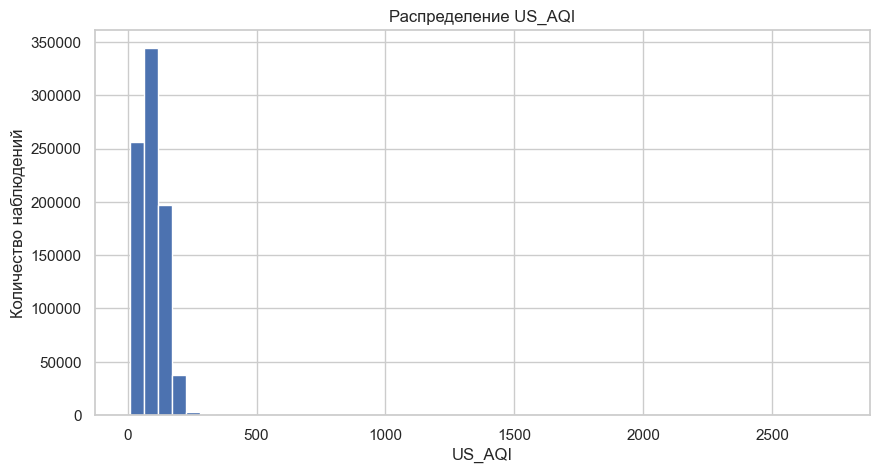

count    842015.000000
mean         96.804419
std          70.784455
min           9.000000
25%          59.000000
50%          84.000000
75%         128.000000
max        2742.000000
Name: US_AQI, dtype: float64


In [246]:
plt.figure(figsize=(10, 5))
plt.hist(df["US_AQI"], bins=50)
plt.title("Распределение US_AQI")
plt.xlabel("US_AQI")
plt.ylabel("Количество наблюдений")
plt.show()

print(df["US_AQI"].describe())

Дополнительно построим boxplot для `US_AQI`, чтобы увидеть возможные экстремальные значения.

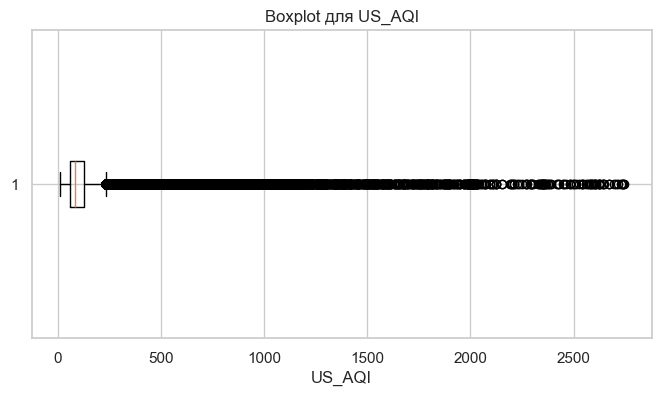

In [247]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["US_AQI"], vert=False)
plt.title("Boxplot для US_AQI")
plt.xlabel("US_AQI")
plt.show()

**Вывод по распределению `US_AQI`.**  
Среднее значение `US_AQI` составляет примерно **96.8**, а медиана — около **84**.  
Это означает, что типичное наблюдение находится ближе к умеренному уровню загрязнения, но распределение имеет правый хвост: встречаются редкие, но очень высокие значения AQI.  
Максимальное значение достигает **2742**, поэтому экстремальные эпизоды загрязнения в данных действительно присутствуют.

,count,percent
AQI_Category,,
Moderate,385769,45.814980
Unhealthy_Sensitive,175071,20.791910
Good,136459,16.206243
Unhealthy,130352,15.480959
Very_Unhealthy,10354,1.229669
Hazardous,4010,0.476239


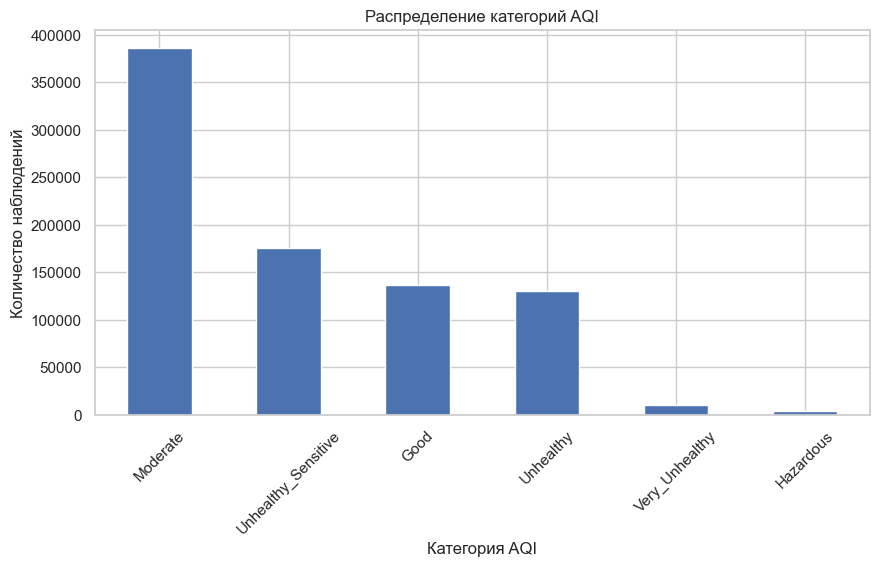

In [248]:
aqi_counts = df["AQI_Category"].value_counts()
aqi_percent = df["AQI_Category"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "count": aqi_counts,
    "percent": aqi_percent
}))

plt.figure(figsize=(10, 5))
aqi_counts.plot(kind="bar")
plt.title("Распределение категорий AQI")
plt.xlabel("Категория AQI")
plt.ylabel("Количество наблюдений")
plt.xticks(rotation=45)
plt.show()

**Вывод по категориям AQI.**  
Чаще всего встречается категория **Moderate** — около **45.8%** наблюдений.  
Далее идут **Unhealthy_Sensitive** — около **20.8%**, **Good** — около **16.2%** и **Unhealthy** — около **15.5%**.  
Категории **Very_Unhealthy** и **Hazardous** встречаются редко, поэтому в будущей классификации классы будут несбалансированы. Из-за этого одной accuracy будет недостаточно: стоит смотреть также precision, recall и F1-score.

In [249]:
pollution_features = [
    "PM2_5_ugm3",
    "PM10_ugm3",
    "CO_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "O3_ugm3",
    "Dust_ugm3",
    "AOD"
]

pollution_features = [col for col in pollution_features if col in df.columns]

features_for_outliers = pollution_features + ["US_AQI"]

features_for_outliers

['PM2_5_ugm3',
 'PM10_ugm3',
 'CO_ugm3',
 'NO2_ugm3',
 'SO2_ugm3',
 'O3_ugm3',
 'Dust_ugm3',
 'AOD',
 'US_AQI']

Построим boxplot для нескольких наиболее важных признаков.

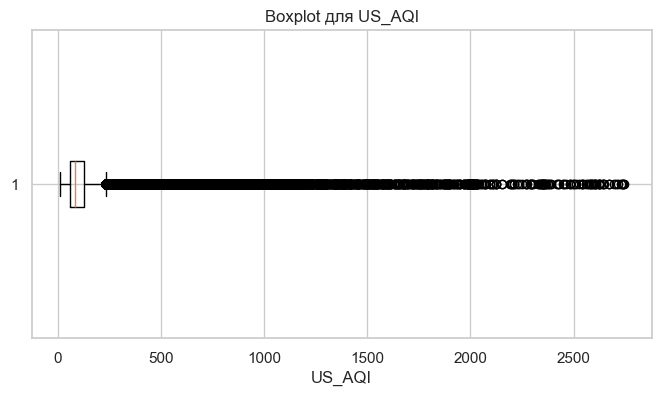

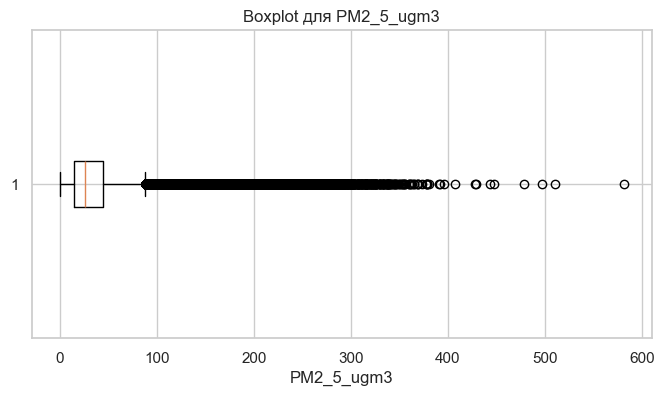

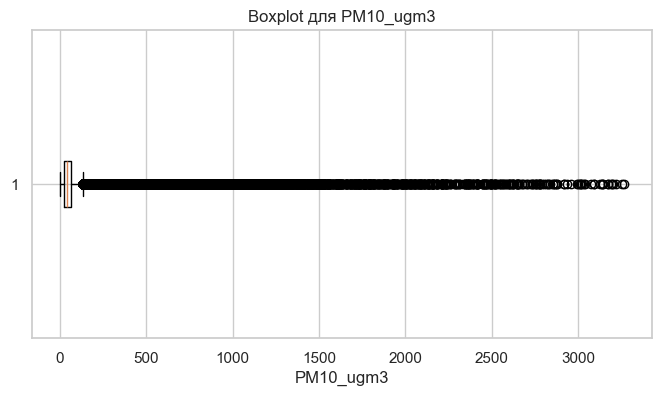

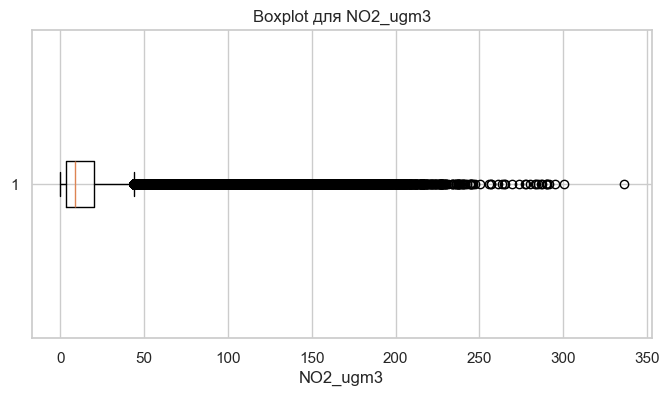

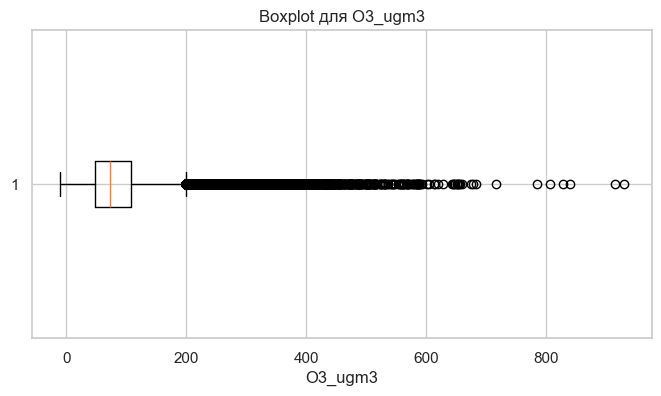

In [250]:
for col in ["US_AQI", "PM2_5_ugm3", "PM10_ugm3", "NO2_ugm3", "O3_ugm3"]:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        plt.boxplot(df[col].dropna(), vert=False)
        plt.title(f"Boxplot для {col}")
        plt.xlabel(col)
        plt.show()

Посчитаем количество и долю выбросов по IQR.

In [251]:
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return len(outliers), len(outliers) / len(data) * 100, lower_bound, upper_bound


outlier_info = []

for col in features_for_outliers:
    count, percent, lower, upper = count_outliers_iqr(df, col)
    outlier_info.append([col, count, percent, lower, upper])

outlier_df = pd.DataFrame(
    outlier_info,
    columns=["feature", "outlier_count", "outlier_percent", "lower_bound", "upper_bound"]
)

outlier_df.sort_values("outlier_percent", ascending=False)

,feature,outlier_count,outlier_percent,lower_bound,upper_bound
6,Dust_ugm3,104006,12.352036,-16.500,27.500
4,SO2_ugm3,73205,8.694026,-16.700,35.300
3,NO2_ugm3,67447,8.010190,-20.600,44.200
2,CO_ugm3,65035,7.723734,-174.500,917.500
1,PM10_ugm3,54094,6.424351,-45.850,133.750
0,PM2_5_ugm3,49144,5.836476,-29.550,88.450
7,AOD,27075,3.215501,-0.315,1.165
5,O3_ugm3,10668,1.266961,-44.500,199.500
8,US_AQI,7136,0.847491,-44.500,231.500


**Вывод по выбросам.**  
Наибольшая доля выбросов наблюдается у `Dust_ugm3`, `SO2_ugm3`, `NO2_ugm3`, `CO_ugm3`, `PM10_ugm3` и `PM2_5_ugm3`.  
Для `US_AQI` доля выбросов по правилу IQR меньше 1%, но именно эти наблюдения соответствуют самым сильным эпизодам загрязнения.  
Поэтому выбросы не удаляются автоматически: для этой предметной области они могут быть не ошибками, а важными экстремальными случаями.

In [252]:
city_aqi = (
    df.groupby("City")["US_AQI"]
      .agg(["mean", "median", "std", "min", "max", "count"])
      .sort_values("mean", ascending=False)
)

city_aqi

,mean,median,std,min,max,count
City,,,,,,
Gurugram,222.521681,159.0,263.245127,12.0,2742.0,29035
Delhi,159.843637,155.0,68.153816,12.0,830.0,29035
Patna,132.851076,141.0,42.781632,14.0,282.0,29035
Lucknow,129.405579,129.0,40.690080,12.0,429.0,29035
Raipur,123.694162,128.0,38.733829,12.0,231.0,29035
Kolkata,122.459755,124.0,53.221426,12.0,312.0,29035
Chandigarh,115.338006,112.0,32.655302,12.0,209.0,29035
Mumbai,114.228999,89.0,55.848234,11.0,369.0,29035
Agartala,105.529292,104.0,48.106059,13.0,233.0,29035


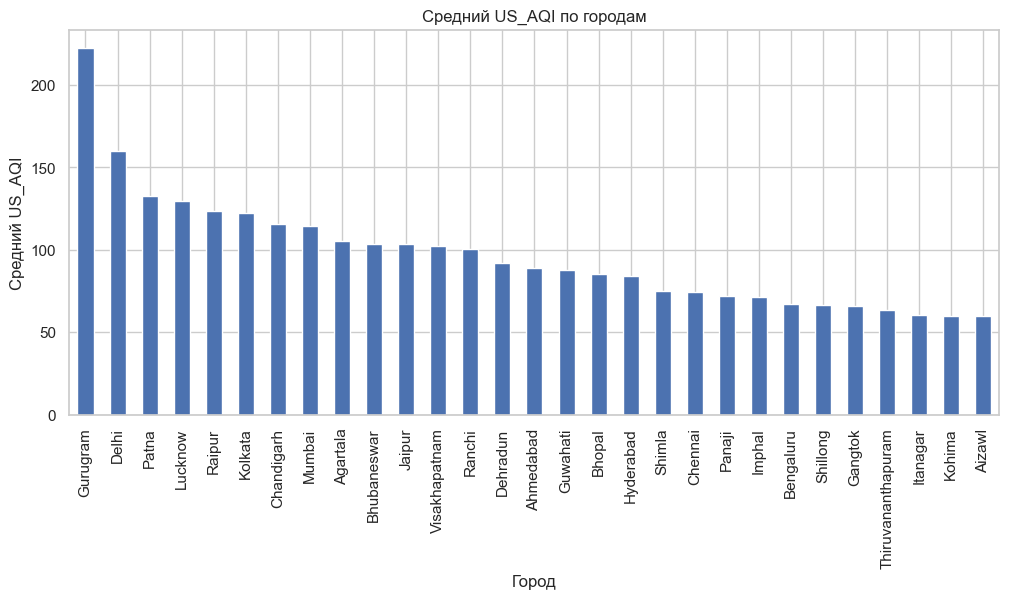

In [253]:
plt.figure(figsize=(12, 5))
city_aqi["mean"].plot(kind="bar")
plt.title("Средний US_AQI по городам")
plt.xlabel("Город")
plt.ylabel("Средний US_AQI")
plt.xticks(rotation=90)
plt.show()

 
Средний AQI позволяет выделить города с наиболее высоким и наиболее низким уровнем загрязнения. Этот анализ важен для дальнейшего моделирования, потому что город может быть сильным объясняющим признаком.

## 10. Топы городов и периодов по уровню загрязнения

После общего сравнения городов отдельно посмотрим несколько топов:

- города с худшей экологией по среднему `US_AQI`;
- города с лучшей экологией по среднему `US_AQI`;
- города с наибольшей долей плохих категорий AQI;
- месяцы с самым высоким средним AQI.

Такие таблицы удобны для интерпретации результатов EDA.

In [254]:
top_bad_cities = city_aqi.head(10)
top_good_cities = city_aqi.tail(10).sort_values("mean")

print("Топ-10 городов с худшей экологией по среднему US_AQI:")
display(top_bad_cities)

print("Топ-10 городов с лучшей экологией по среднему US_AQI:")
display(top_good_cities)

Топ-10 городов с худшей экологией по среднему US_AQI:


,mean,median,std,min,max,count
City,,,,,,
Gurugram,222.521681,159.0,263.245127,12.0,2742.0,29035
Delhi,159.843637,155.0,68.153816,12.0,830.0,29035
Patna,132.851076,141.0,42.781632,14.0,282.0,29035
Lucknow,129.405579,129.0,40.690080,12.0,429.0,29035
Raipur,123.694162,128.0,38.733829,12.0,231.0,29035
Kolkata,122.459755,124.0,53.221426,12.0,312.0,29035
Chandigarh,115.338006,112.0,32.655302,12.0,209.0,29035
Mumbai,114.228999,89.0,55.848234,11.0,369.0,29035
Agartala,105.529292,104.0,48.106059,13.0,233.0,29035


Топ-10 городов с лучшей экологией по среднему US_AQI:


,mean,median,std,min,max,count
City,,,,,,
Aizawl,59.562046,51.0,34.780684,9.0,215.0,29035
Kohima,60.003616,52.0,30.664358,10.0,198.0,29035
Itanagar,60.253659,54.0,26.015185,12.0,185.0,29035
Thiruvananthapuram,63.228827,55.0,27.631320,15.0,214.0,29035
Gangtok,65.990770,60.0,30.964459,12.0,181.0,29035
Shillong,66.272499,56.0,33.901812,13.0,200.0,29035
Bengaluru,66.771242,66.0,32.164338,12.0,204.0,29035
Imphal,71.034028,64.0,31.048418,14.0,211.0,29035
Panaji,71.733804,65.0,31.425590,14.0,195.0,29035


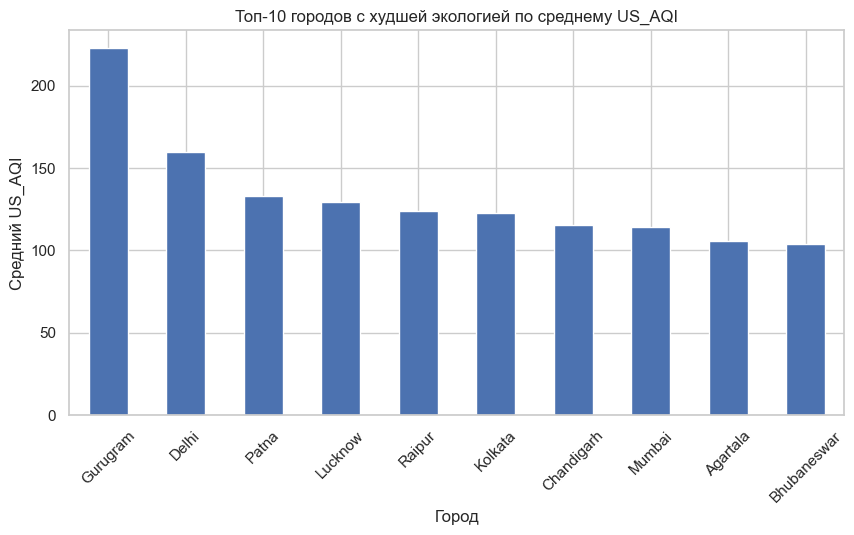

In [255]:
plt.figure(figsize=(10, 5))
top_bad_cities["mean"].plot(kind="bar")
plt.title("Топ-10 городов с худшей экологией по среднему US_AQI")
plt.xlabel("Город")
plt.ylabel("Средний US_AQI")
plt.xticks(rotation=45)
plt.show()

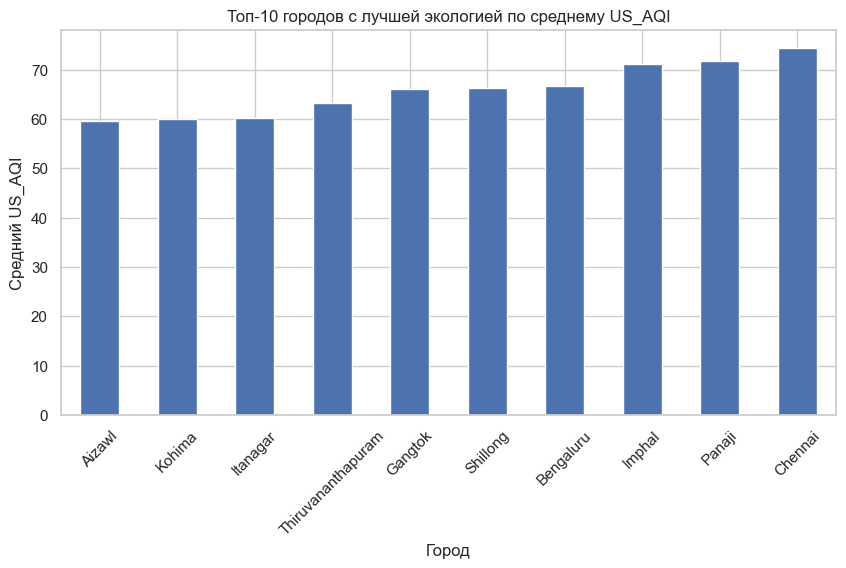

In [256]:
plt.figure(figsize=(10, 5))
top_good_cities["mean"].plot(kind="bar")
plt.title("Топ-10 городов с лучшей экологией по среднему US_AQI")
plt.xlabel("Город")
plt.ylabel("Средний US_AQI")
plt.xticks(rotation=45)
plt.show()

**Вывод по топу городов.**  
Худшие показатели по среднему AQI имеют **Gurugram**, **Delhi**, **Patna**, **Lucknow** и **Raipur**.  
Лучшие показатели среди рассматриваемых городов наблюдаются у **Aizawl**, **Kohima**, **Itanagar**, **Thiruvananthapuram** и **Gangtok**.  
Разрыв между худшими и лучшими городами большой, поэтому географический фактор является одним из ключевых в этом датасете.

In [257]:
bad_categories = ["Unhealthy_Sensitive", "Unhealthy", "Very_Unhealthy", "Hazardous"]

city_category_table = pd.crosstab(df["City"], df["AQI_Category"], normalize="index") * 100

for category in bad_categories:
    if category not in city_category_table.columns:
        city_category_table[category] = 0

city_category_table["bad_aqi_share"] = city_category_table[bad_categories].sum(axis=1)

top_bad_share_cities = city_category_table["bad_aqi_share"].sort_values(ascending=False).head(10)

print("Топ-10 городов по доле плохих категорий AQI:")
display(top_bad_share_cities)

Топ-10 городов по доле плохих категорий AQI:


City
Gurugram         90.332357
Delhi            89.826072
Patna            72.278285
Lucknow          70.597555
Raipur           68.930601
Chandigarh       60.354744
Kolkata          59.056311
Agartala         51.527467
Visakhapatnam    46.109867
Bhubaneswar      45.875667
Name: bad_aqi_share, dtype: float64

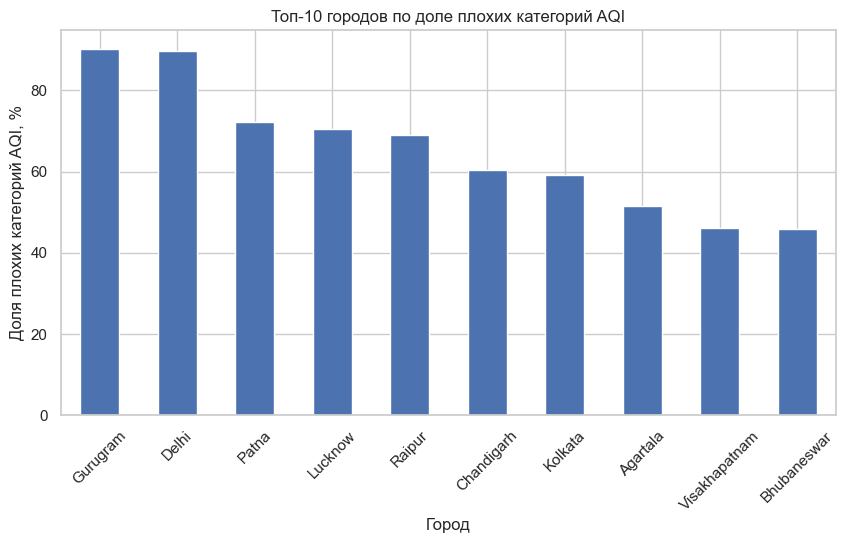

In [258]:
plt.figure(figsize=(10, 5))
top_bad_share_cities.plot(kind="bar")
plt.title("Топ-10 городов по доле плохих категорий AQI")
plt.xlabel("Город")
plt.ylabel("Доля плохих категорий AQI, %")
plt.xticks(rotation=45)
plt.show()

**Вывод по доле плохих категорий AQI.**  
По доле плохих категорий AQI снова выделяются **Gurugram** и **Delhi**: в этих городах плохие категории встречаются примерно в 90% наблюдений.  
Также высокие значения имеют **Patna**, **Lucknow** и **Raipur**.  
Это подтверждает вывод, что проблема загрязнения воздуха в этих городах носит не единичный, а устойчивый характер.

In [259]:
month_aqi = df.groupby("Month")["US_AQI"].mean()
top_bad_months = month_aqi.sort_values(ascending=False).head(5)

print("Топ-5 месяцев с самым высоким средним US_AQI:")
display(top_bad_months)

Топ-5 месяцев с самым высоким средним US_AQI:


Month
1     128.422661
3     116.325501
2     113.649915
11    112.508906
12    112.324682
Name: US_AQI, dtype: float64

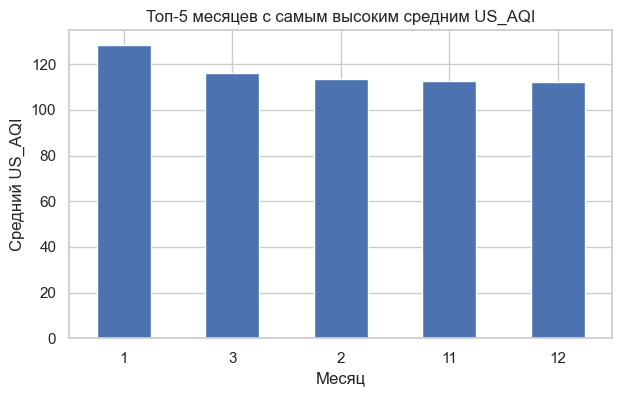

In [260]:
plt.figure(figsize=(7, 4))
top_bad_months.plot(kind="bar")
plt.title("Топ-5 месяцев с самым высоким средним US_AQI")
plt.xlabel("Месяц")
plt.ylabel("Средний US_AQI")
plt.xticks(rotation=0)
plt.show()

**Вывод по самым загрязнённым месяцам.**  
Самые высокие средние значения AQI наблюдаются в **январе**, **марте**, **феврале**, **ноябре** и **декабре**.  
Это показывает, что ухудшение качества воздуха сильнее проявляется в холодные и переходные месяцы, а сезонность является важной частью анализа.

**Вывод по городам.**  
Самые высокие средние значения `US_AQI` наблюдаются в **Gurugram**, **Delhi**, **Patna**, **Lucknow** и **Raipur**.  
Особенно выделяется **Gurugram**: его средний AQI выше 220, а максимум достигает 2742.  
Самые низкие средние значения AQI среди городов показывают **Aizawl**, **Kohima**, **Itanagar**, **Thiruvananthapuram** и **Gangtok**.  
Это говорит о заметных различиях в качестве воздуха между городами, поэтому признак `City` важен для дальнейшего анализа и моделей.

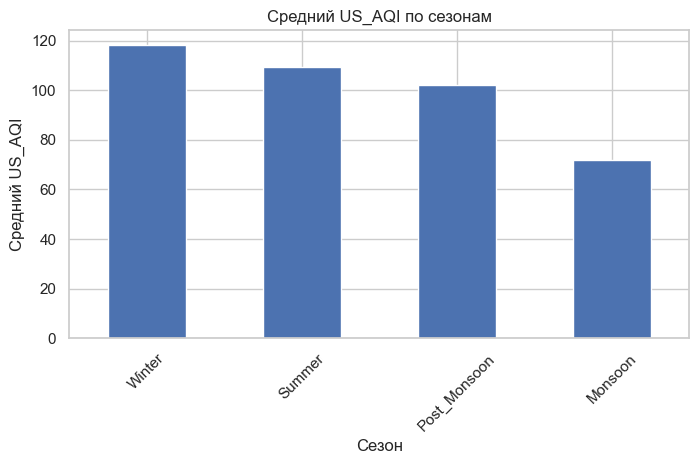

Season
Winter          118.264744
Summer          109.252264
Post_Monsoon    102.137895
Monsoon          71.895254
Name: US_AQI, dtype: float64

In [261]:
season_aqi = df.groupby("Season")["US_AQI"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
season_aqi.plot(kind="bar")
plt.title("Средний US_AQI по сезонам")
plt.xlabel("Сезон")
plt.ylabel("Средний US_AQI")
plt.xticks(rotation=45)
plt.show()

season_aqi


Средний AQI заметно различается между сезонами, значит сезонность является важным фактором качества воздуха.

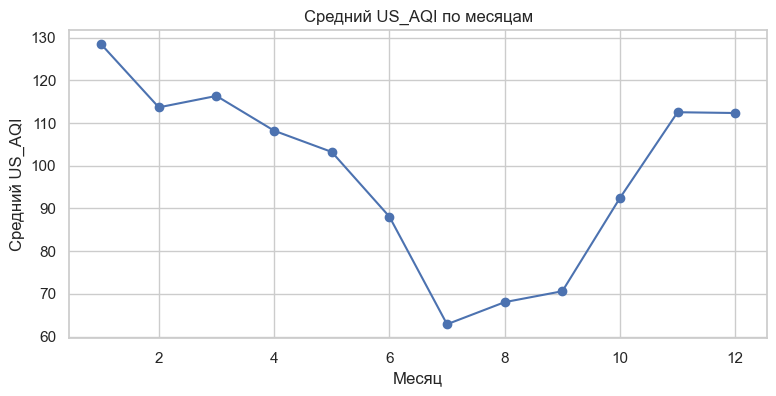

Month
1     128.422661
2     113.649915
3     116.325501
4     108.187963
5     103.208998
6      88.067098
7      62.871694
8      68.046201
9      70.602000
10     92.435982
11    112.508906
12    112.324682
Name: US_AQI, dtype: float64

In [262]:


plt.figure(figsize=(9, 4))
plt.plot(month_aqi.index, month_aqi.values, marker="o")
plt.title("Средний US_AQI по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Средний US_AQI")
plt.grid(True)
plt.show()

month_aqi


График по месяцам помогает увидеть более детальную сезонную динамику. Пики на этом графике могут соответствовать периодам ухудшения качества воздуха.

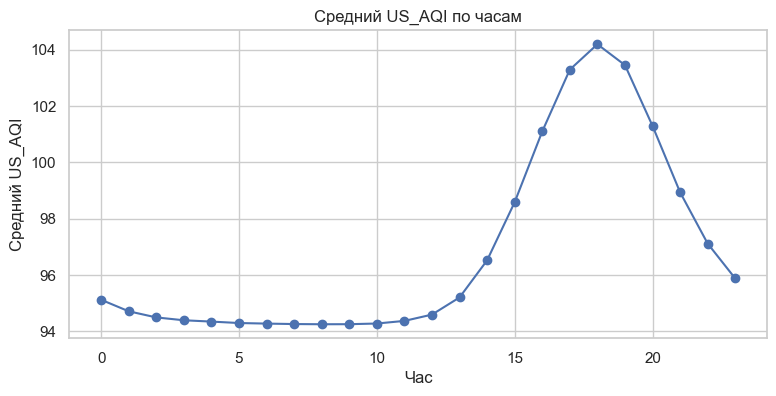

Hour
0    95.125439
1    94.716523
2    94.498845
3    94.397764
4    94.350960
Name: US_AQI, dtype: float64

In [263]:
hour_aqi = df.groupby("Hour")["US_AQI"].mean()

plt.figure(figsize=(9, 4))
plt.plot(hour_aqi.index, hour_aqi.values, marker="o")
plt.title("Средний US_AQI по часам")
plt.xlabel("Час")
plt.ylabel("Средний US_AQI")
plt.grid(True)
plt.show()

hour_aqi.head()


AQI меняется в течение суток, признак `Hour` может быть полезен для будущей модели. Суточные различия могут быть связаны с транспортной активностью, погодными условиями и накоплением загрязнителей.

**Вывод по часам.**  
Наиболее высокие средние значения AQI наблюдаются вечером: примерно с **17 до 20 часов**.  
Это может быть связано с суточным накоплением загрязнителей, транспортной активностью и изменением погодных условий в течение дня.  
Следовательно, признак `Hour` имеет смысл оставить для дальнейшего моделирования.

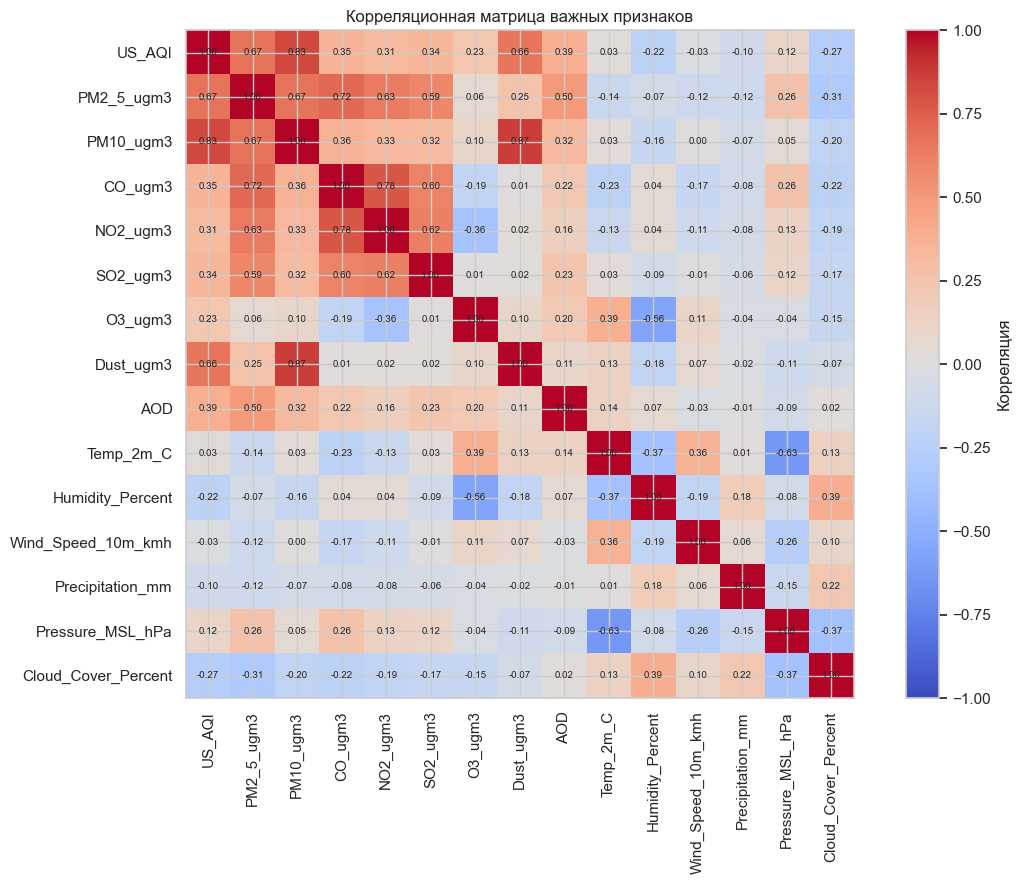

In [264]:
corr_features = [
    "US_AQI",
    "PM2_5_ugm3",
    "PM10_ugm3",
    "CO_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "O3_ugm3",
    "Dust_ugm3",
    "AOD",
    "Temp_2m_C",
    "Humidity_Percent",
    "Wind_Speed_10m_kmh",
    "Precipitation_mm",
    "Pressure_MSL_hPa",
    "Cloud_Cover_Percent"
]

corr_features = [col for col in corr_features if col in df.columns]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Корреляция")
plt.xticks(range(len(corr_features)), corr_features, rotation=90)
plt.yticks(range(len(corr_features)), corr_features)
plt.title("Корреляционная матрица важных признаков")

for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        value = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

Отдельно выведем корреляции признаков с `US_AQI`.

In [265]:
corr_with_target = (
    corr_matrix["US_AQI"]
    .sort_values(ascending=False)
    .drop("US_AQI")
)

corr_with_target

PM10_ugm3              0.829666
PM2_5_ugm3             0.667822
Dust_ugm3              0.663002
AOD                    0.387045
CO_ugm3                0.354770
SO2_ugm3               0.339538
NO2_ugm3               0.314661
O3_ugm3                0.226693
Pressure_MSL_hPa       0.116554
Temp_2m_C              0.027512
Wind_Speed_10m_kmh    -0.026161
Precipitation_mm      -0.096940
Humidity_Percent      -0.223264
Cloud_Cover_Percent   -0.272400
Name: US_AQI, dtype: float64

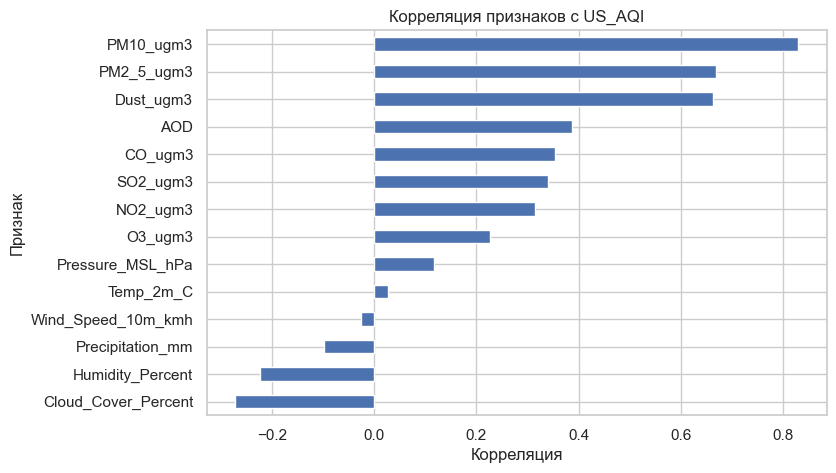

In [266]:
plt.figure(figsize=(8, 5))
corr_with_target.sort_values().plot(kind="barh")
plt.title("Корреляция признаков с US_AQI")
plt.xlabel("Корреляция")
plt.ylabel("Признак")
plt.show()


Наиболее сильная связь с `US_AQI` ожидается у загрязнителей, так как индекс качества воздуха рассчитывается на основе концентраций вредных веществ. Погодные признаки могут иметь более слабую корреляцию, но они важны для более честной модели, если не использовать прямые показатели загрязнителей.

**Вывод по корреляциям.**  
Сильнее всего с `US_AQI` связаны загрязнители: `PM10_ugm3` имеет корреляцию около **0.83**, `PM2_5_ugm3` — около **0.67**, `Dust_ugm3` — около **0.66**.  
Также положительная связь есть у `AOD`, `CO_ugm3`, `SO2_ugm3` и `NO2_ugm3`.  
Отрицательная связь наблюдается у `Cloud_Cover_Percent`, `Humidity_Percent` и `Precipitation_mm`: при большей облачности, влажности и осадках AQI в среднем ниже.  
Это подтверждает, что загрязнители являются основными факторами AQI, а погодные признаки могут дополнительно объяснять изменения качества воздуха.

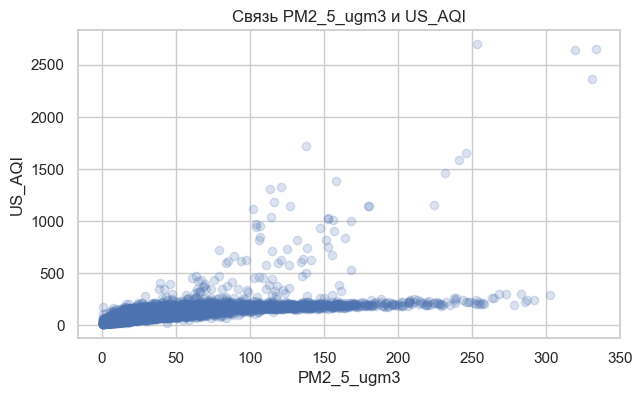

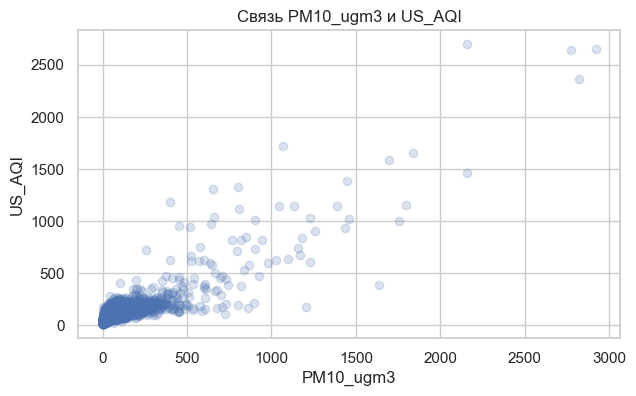

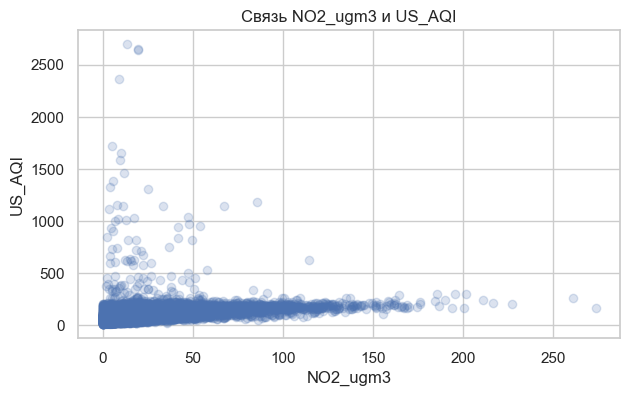

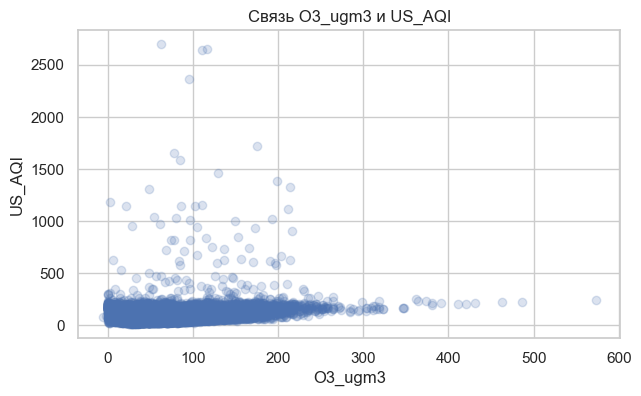

In [267]:
sample_df = df.sample(n=20000, random_state=42)

for col in ["PM2_5_ugm3", "PM10_ugm3", "NO2_ugm3", "O3_ugm3"]:
    if col in sample_df.columns:
        plt.figure(figsize=(7, 4))
        plt.scatter(sample_df[col], sample_df["US_AQI"], alpha=0.2)
        plt.title(f"Связь {col} и US_AQI")
        plt.xlabel(col)
        plt.ylabel("US_AQI")
        plt.show()


Точечные графики позволяют визуально оценить, насколько рост концентрации загрязнителя связан с ростом AQI. Если зависимость заметна, такой признак будет важен для модели регрессии или классификации.

**Вывод по scatter plot.**  
Точечные графики показывают, что при росте концентраций `PM2_5_ugm3`, `PM10_ugm3` и некоторых других загрязнителей значение `US_AQI` обычно увеличивается.  
Связь не идеально линейная, но общий тренд заметен.  
Это значит, что загрязнители будут важны для технически сильной модели, однако для более исследовательской постановки можно отдельно попробовать модель без прямого использования загрязнителей.

In [268]:
print("Финальный размер датасета:", df.shape)
print("Количество пропусков:", df.isna().sum().sum())
print("Количество дубликатов:", df.duplicated().sum())

print("\nСредний US_AQI:", round(df["US_AQI"].mean(), 2))
print("Медианный US_AQI:", round(df["US_AQI"].median(), 2))

print("\nТоп-5 городов по среднему US_AQI:")
display(city_aqi.head(5))

print("\nТоп-5 признаков с наибольшей положительной корреляцией с US_AQI:")
display(corr_with_target.head(5))

print("\nТоп-5 признаков с наибольшей отрицательной корреляцией с US_AQI:")
display(corr_with_target.tail(5))

print("\nПризнаки с наибольшей долей выбросов:")
display(outlier_df.sort_values("outlier_percent", ascending=False).head(5))

Финальный размер датасета: (842015, 63)
Количество пропусков: 0
Количество дубликатов: 0

Средний US_AQI: 96.8
Медианный US_AQI: 84.0

Топ-5 городов по среднему US_AQI:


,mean,median,std,min,max,count
City,,,,,,
Gurugram,222.521681,159.0,263.245127,12.0,2742.0,29035
Delhi,159.843637,155.0,68.153816,12.0,830.0,29035
Patna,132.851076,141.0,42.781632,14.0,282.0,29035
Lucknow,129.405579,129.0,40.690080,12.0,429.0,29035
Raipur,123.694162,128.0,38.733829,12.0,231.0,29035



Топ-5 признаков с наибольшей положительной корреляцией с US_AQI:


PM10_ugm3     0.829666
PM2_5_ugm3    0.667822
Dust_ugm3     0.663002
AOD           0.387045
CO_ugm3       0.354770
Name: US_AQI, dtype: float64


Топ-5 признаков с наибольшей отрицательной корреляцией с US_AQI:


Temp_2m_C              0.027512
Wind_Speed_10m_kmh    -0.026161
Precipitation_mm      -0.096940
Humidity_Percent      -0.223264
Cloud_Cover_Percent   -0.272400
Name: US_AQI, dtype: float64


Признаки с наибольшей долей выбросов:


,feature,outlier_count,outlier_percent,lower_bound,upper_bound
6,Dust_ugm3,104006,12.352036,-16.50,27.50
4,SO2_ugm3,73205,8.694026,-16.70,35.30
3,NO2_ugm3,67447,8.010190,-20.60,44.20
2,CO_ugm3,65035,7.723734,-174.50,917.50
1,PM10_ugm3,54094,6.424351,-45.85,133.75


## Общий вывод по EDA

В ходе разведывательного анализа была изучена структура данных о загрязнении воздуха в городах Индии.  
Датасет содержит большое количество почасовых наблюдений, что позволяет анализировать качество воздуха по городам, времени суток, месяцам и сезонам.

На этапе предобработки были удалены полностью пустые признаки, обработаны пропуски и проверены дубликаты.  
Целевая переменная `US_AQI` подходит для будущей задачи регрессии, а `AQI_Category` — для задачи классификации.

В данных присутствуют выбросы, особенно в признаках загрязнения и AQI. Они не удалялись автоматически, так как могут отражать реальные периоды сильного загрязнения воздуха.

Корреляционный анализ показал, какие признаки сильнее всего связаны с `US_AQI`.  
При дальнейшем моделировании важно учитывать, что AQI рассчитывается на основе загрязнителей. Поэтому можно рассмотреть два варианта:

1. модель с использованием загрязнителей — более простая и техническая;
2. модель только на погодных, временных и географических признаках — более содержательная и исследовательская.

Дальнейшая часть проекта будет посвящена построению модели регрессии для предсказания `US_AQI` и модели классификации для предсказания `AQI_Category`.

In [269]:
df.to_csv("india_aqi_cleaned.csv", index=False)

print("Файл сохранён: india_aqi_cleaned.csv")

Файл сохранён: india_aqi_cleaned.csv


---

# 14. Построение моделей машинного обучения

В этой части продолжаем выполненный EDA и строим два блока моделей:

1. **Регрессия** — предсказание числового значения `US_AQI`.
2. **Классификация** — предсказание категории качества воздуха `AQI_Category`.


## 14.1. Подготовка данных для моделей

Для регрессии целевая переменная — `US_AQI`, поэтому её убираем из признаков.

Для классификации целевая переменная — `AQI_Category`. При этом `US_AQI` также нельзя использовать как признак, потому что категория AQI строится именно по этому числу. Если оставить `US_AQI`, получится утечка данных и качество классификации будет искусственно завышенным.


In [270]:
target_reg = "US_AQI"
target_clf = "AQI_Category"
cols_to_drop = [
    'US_AQI', 'AQI_Category', 'Datetime', 'City', 'State', 
    'PM25_Category_India', 'Predominant_Pollutant',
    'US_AQI_PM25', 'US_AQI_PM10', 'US_AQI_NO2', 'US_AQI_O3', 'US_AQI_CO', 
    'EU_AQI', 'EU_AQI_PM25', 'EU_AQI_PM10',
    'PM2_5_ugm3', 'PM10_ugm3', 'PM_Ratio', 'CO_ugm3', 'NO2_ugm3', 
    'SO2_ugm3', 'O3_ugm3', 'Dust_ugm3', 'AOD'
]
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
model_features = [
    col for col in numeric_features
    if col != target_reg and col not in cols_to_drop
]
required_columns = model_features + [target_reg, target_clf]
model_df = df[required_columns].dropna().copy()

print("Размер таблицы для моделирования:", model_df.shape)
print("Количество признаков:", len(model_features))
print("Целевая переменная для регрессии:", target_reg)
print("Целевая переменная для классификации:", target_clf)


Размер таблицы для моделирования: (842015, 37)
Количество признаков: 35
Целевая переменная для регрессии: US_AQI
Целевая переменная для классификации: AQI_Category


In [271]:
print("Признаки для моделей:")
print(model_features)


Признаки для моделей:
['Latitude', 'Longitude', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week', 'Week_of_Year', 'Is_Weekend', 'Quarter', 'Temp_2m_C', 'Humidity_Percent', 'Dew_Point_C', 'Wind_Speed_10m_kmh', 'Wind_Dir_10m', 'Wind_Gusts_kmh', 'Wind_Stagnation', 'Precipitation_mm', 'Rain_mm', 'Is_Raining', 'Heavy_Rain', 'Pressure_MSL_hPa', 'Surface_Pressure_hPa', 'Solar_Radiation_Wm2', 'Direct_Radiation_Wm2', 'Diffuse_Radiation_Wm2', 'Cloud_Cover_Percent', 'Cloud_Low_Percent', 'Cloud_Mid_Percent', 'Cloud_High_Percent', 'Is_Daytime', 'Sunshine_Seconds', 'Temp_Inversion', 'Festival_Period', 'Crop_Burning_Season']


**Комментарий.**  
Для моделей используются только числовые признаки.

# 15. Регрессия

Задача регрессии — предсказать числовое значение `US_AQI`.

Используем **линейную регрессию**, потому что целевая переменная числовая.  

## 15.1. Подбор количества признаков

Количество признаков выберем не случайно: отсортируем числовые признаки по корреляции с `US_AQI` и построим график качества модели при разном числе признаков.

Метрики:

- `MAE` — средняя абсолютная ошибка в пунктах AQI;
- `RMSE` — средняя ошибка с усиленным штрафом за крупные промахи;
- `R²` — доля изменчивости `US_AQI`, объяснённая моделью;
- `MAPE` — относительная ошибка в процентах.  
  Эта метрика добавлена отдельно, потому что она хорошо читается в выводе: показывает ошибку не в пунктах AQI, а в процентах.


In [272]:
feature_corr = (
    model_df[model_features + [target_reg]]
    .corr(numeric_only=True)[target_reg]
    .drop(target_reg)
    .abs()
    .sort_values(ascending=False)
)

print("Топ признаков по модулю корреляции с US_AQI:")
display(feature_corr.head(15))


Топ признаков по модулю корреляции с US_AQI:


Cloud_Cover_Percent     0.272400
Cloud_High_Percent      0.243273
Humidity_Percent        0.223264
Surface_Pressure_hPa    0.222913
Is_Raining              0.215506
Cloud_Low_Percent       0.213001
Cloud_Mid_Percent       0.184112
Dew_Point_C             0.163129
Longitude               0.154140
Latitude                0.153996
Pressure_MSL_hPa        0.116554
Month                   0.110888
Week_of_Year            0.110110
Quarter                 0.110044
Rain_mm                 0.096947
Name: US_AQI, dtype: float64

In [273]:
max_features_to_check = min(15, len(feature_corr))
feature_selection_results = []

for n_features in range(1, max_features_to_check + 1):
    selected_features = feature_corr.head(n_features).index.tolist()

    X_tmp = model_df[selected_features]
    y_tmp = model_df[target_reg]

    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X_tmp, y_tmp, test_size=0.2, random_state=RANDOM_STATE
    )

    scaler_tmp = StandardScaler()
    X_train_tmp_scaled = scaler_tmp.fit_transform(X_train_tmp)
    X_test_tmp_scaled = scaler_tmp.transform(X_test_tmp)

    model_tmp = LinearRegression()
    model_tmp.fit(X_train_tmp_scaled, y_train_tmp)
    y_pred_tmp = model_tmp.predict(X_test_tmp_scaled)

    feature_selection_results.append({
        "n_features": n_features,
        "R2": r2_score(y_test_tmp, y_pred_tmp),
        "MAE": mean_absolute_error(y_test_tmp, y_pred_tmp),
        "RMSE": np.sqrt(mean_squared_error(y_test_tmp, y_pred_tmp))
    })

feature_selection_results = pd.DataFrame(feature_selection_results)
display(feature_selection_results)


,n_features,R2,MAE,RMSE
0,1,0.074067,37.474491,68.214888
1,2,0.074088,37.468932,68.214123
2,3,0.089879,36.975127,67.629940
3,4,0.133837,34.944653,65.976509
4,5,0.139995,34.596495,65.741543
5,6,0.142137,34.474088,65.659629
6,7,0.142175,34.475403,65.658185
7,8,0.159122,33.446893,65.006385
8,9,0.162751,33.402851,64.865953
9,10,0.196594,32.007695,63.541445


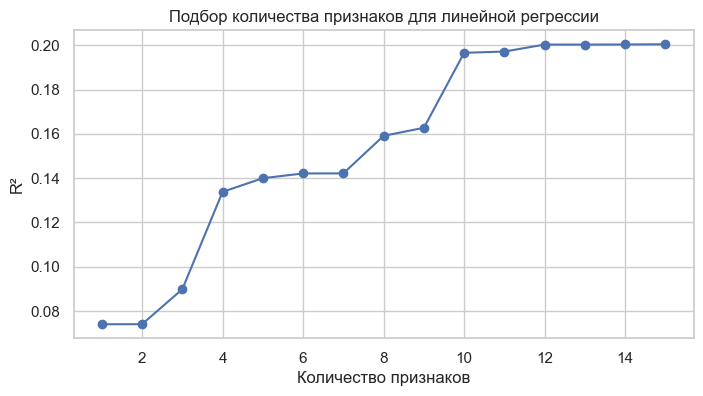

In [274]:
plt.figure(figsize=(8, 4))
plt.plot(feature_selection_results["n_features"], feature_selection_results["R2"], marker="o")
plt.title("Подбор количества признаков для линейной регрессии")
plt.xlabel("Количество признаков")
plt.ylabel("R²")
plt.grid(True)
plt.show()


In [275]:
best_row = feature_selection_results.sort_values("R2", ascending=False).iloc[0]
best_n_features = int(best_row["n_features"])
regression_features = feature_corr.head(best_n_features).index.tolist()

print("Оптимальное количество признаков:", best_n_features)
print("Выбранные признаки:")
print(regression_features)


Оптимальное количество признаков: 15
Выбранные признаки:
['Cloud_Cover_Percent', 'Cloud_High_Percent', 'Humidity_Percent', 'Surface_Pressure_hPa', 'Is_Raining', 'Cloud_Low_Percent', 'Cloud_Mid_Percent', 'Dew_Point_C', 'Longitude', 'Latitude', 'Pressure_MSL_hPa', 'Month', 'Week_of_Year', 'Quarter', 'Rain_mm']


**Вывод по подбору признаков.**  
Количество признаков выбирается по максимальному `R²`. Если после добавления новых признаков качество почти не растёт, нет смысла усложнять модель: она становится тяжелее, но почти не выигрывает в точности.


## 15.2. Обучение линейной регрессии

In [276]:
X_reg = model_df[regression_features]
y_reg = model_df[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_scaler = StandardScaler()
X_train_reg_scaled = reg_scaler.fit_transform(X_train_reg)
X_test_reg_scaled = reg_scaler.transform(X_test_reg)

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train_reg_scaled, y_train_reg)

y_pred_reg = linear_regression_model.predict(X_test_reg_scaled)

y_test_reg_values = y_test_reg.to_numpy()
nonzero_mask = y_test_reg_values != 0

mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mse_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)
mape_reg = np.mean(
    np.abs((y_test_reg_values[nonzero_mask] - y_pred_reg[nonzero_mask]) / y_test_reg_values[nonzero_mask])
) * 100

regression_metrics = pd.DataFrame({
    "metric": ["MAE", "MSE", "RMSE", "MAPE, %", "R2"],
    "value": [mae_reg, mse_reg, rmse_reg, mape_reg, r2_reg]
})

display(regression_metrics)


,metric,value
0,MAE,31.730455
1,MSE,4018.097268
2,RMSE,63.388463
3,"MAPE, %",39.154559
4,R2,0.200458


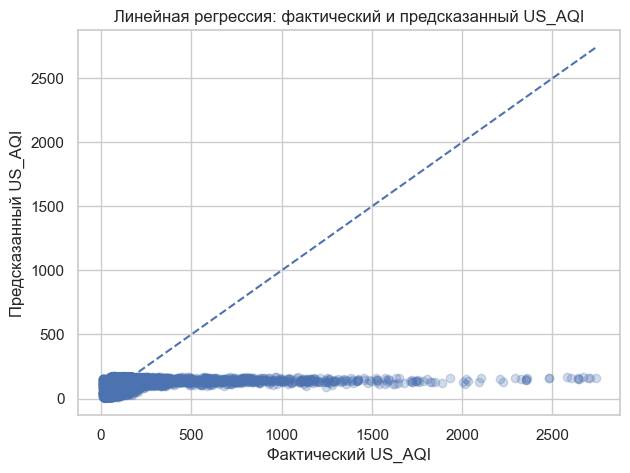

In [277]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.25)
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    linestyle="--"
)
plt.title("Линейная регрессия: фактический и предсказанный US_AQI")
plt.xlabel("Фактический US_AQI")
plt.ylabel("Предсказанный US_AQI")
plt.grid(True)
plt.show()


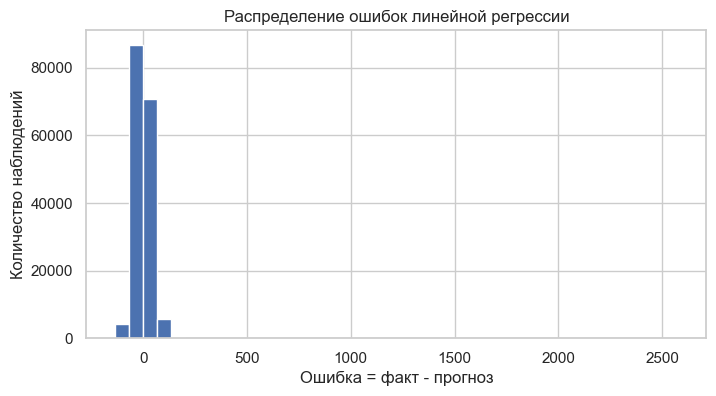

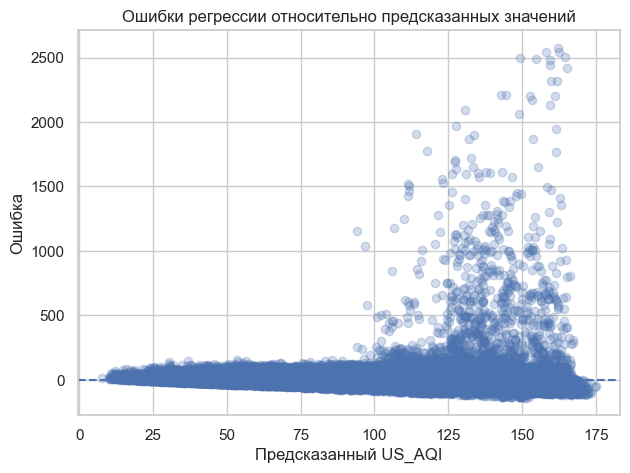

In [278]:
residuals_reg = y_test_reg_values - y_pred_reg

plt.figure(figsize=(8, 4))
plt.hist(residuals_reg, bins=40)
plt.title("Распределение ошибок линейной регрессии")
plt.xlabel("Ошибка = факт - прогноз")
plt.ylabel("Количество наблюдений")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_reg, residuals_reg, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.title("Ошибки регрессии относительно предсказанных значений")
plt.xlabel("Предсказанный US_AQI")
plt.ylabel("Ошибка")
plt.grid(True)
plt.show()


,feature,coefficient
3,Surface_Pressure_hPa,22.193478
9,Latitude,16.090767
1,Cloud_High_Percent,-7.748628
8,Longitude,-7.561189
7,Dew_Point_C,-6.192718
4,Is_Raining,-3.875458
5,Cloud_Low_Percent,-3.800500
10,Pressure_MSL_hPa,3.387745
11,Month,-3.256333
2,Humidity_Percent,-2.621327


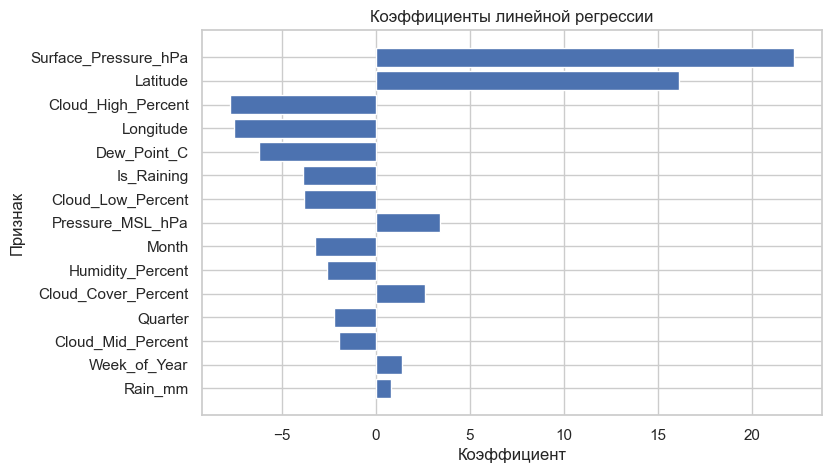

In [279]:
regression_coefficients = pd.DataFrame({
    "feature": regression_features,
    "coefficient": linear_regression_model.coef_
}).sort_values("coefficient", key=lambda x: x.abs(), ascending=False)

display(regression_coefficients)

plt.figure(figsize=(8, 5))
plt.barh(regression_coefficients["feature"], regression_coefficients["coefficient"])
plt.title("Коэффициенты линейной регрессии")
plt.xlabel("Коэффициент")
plt.ylabel("Признак")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


## 15.3. Итог по регрессии

In [315]:
mean_aqi_reg = y_test_reg.mean()
mae_share = (mae_reg / mean_aqi_reg * 100) if mean_aqi_reg != 0 else np.nan

print("Вывод по регрессии:")
print(f"Средний US_AQI на тестовой выборке: {mean_aqi_reg:.2f}")
print(f"MAE = {mae_reg:.2f}")
print(f"RMSE = {rmse_reg:.2f}.")
print(f"MAPE = {mape_reg:.2f}%.")
print(f"R² = {r2_reg:.3f}.")

if r2_reg >= 0.8 and mape_reg < 20:
    print("Итог: регрессия выполнена очень хорошо. Модель объясняет большую часть изменения US_AQI и ошибается относительно немного.")
elif r2_reg >= 0.6 and mape_reg < 30:
    print("Итог: регрессия выполнена хорошо. Модель уверенно улавливает основные закономерности в данных.")
elif r2_reg >= 0.4 and mape_reg < 40:
    print("Итог: регрессия выполнена удовлетворительно. Общая тенденция найдена, но точность прогноза ограничена.")
else:
    print("Итог: качество регрессии слабое. Линейной модели недостаточно, вероятно нужны более сложные зависимости или дополнительные признаки.")


Вывод по регрессии:
Средний US_AQI на тестовой выборке: 96.82
MAE = 31.73
RMSE = 63.39.
MAPE = 39.15%.
R² = 0.200.
Итог: качество регрессии слабое. Линейной модели недостаточно, вероятно нужны более сложные зависимости или дополнительные признаки.


## 15.2. Полиномиальная регрессия

In [310]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
features = [
    'PM2_5_ugm3', 'PM10_ugm3', 'CO_ugm3', 'NO2_ugm3', 
    'SO2_ugm3', 'O3_ugm3', 'Temp_2m_C', 'Humidity_Percent'
]
target = 'US_AQI'
# Удаляем строки, где есть пропуски в нужных нам колонках
df_model = df.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

# Разбиваем на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
# Создаем пайплайн: 
# 1. StandardScaler - масштабирует признаки (очень важно для полиномов!)
# 2. PolynomialFeatures - создает нелинейные признаки (квадраты и попарные произведения)
# 3. LinearRegression - строит линейную регрессию поверх новых признаков
poly_model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

# Обучаем модель
poly_model.fit(X_train, y_train)

Обучение полиномиальной регрессии (degree=2)...
Обучение завершено!


In [311]:
# Делаем предсказания
y_pred_train_poly = poly_model.predict(X_train)
y_pred_test_poly = poly_model.predict(X_test)

# Выводим метрики
print("=== Полиномиальная регрессия (Степень 2) ===")
print("Метрики на тренировочной выборке:")
print(f"MAE:  {mean_absolute_error(y_train, y_pred_train_poly):.2f}")
print(f"MSE:  {mean_squared_error(y_train, y_pred_train_poly):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_poly)):.2f}")
print(f"R2:   {r2_score(y_train, y_pred_train_poly):.4f}\n")

print("Метрики на тестовой выборке:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_test_poly):.2f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred_test_poly):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_poly)):.2f}")
print(f"R2:   {r2_score(y_test, y_pred_test_poly):.4f}")

=== Полиномиальная регрессия (Степень 2) ===
Метрики на тренировочной выборке:
MAE:  16.48
MSE:  1120.00
RMSE: 33.47
R2:   0.7763

Метрики на тестовой выборке:
MAE:  16.53
MSE:  1189.40
RMSE: 34.49
R2:   0.7633


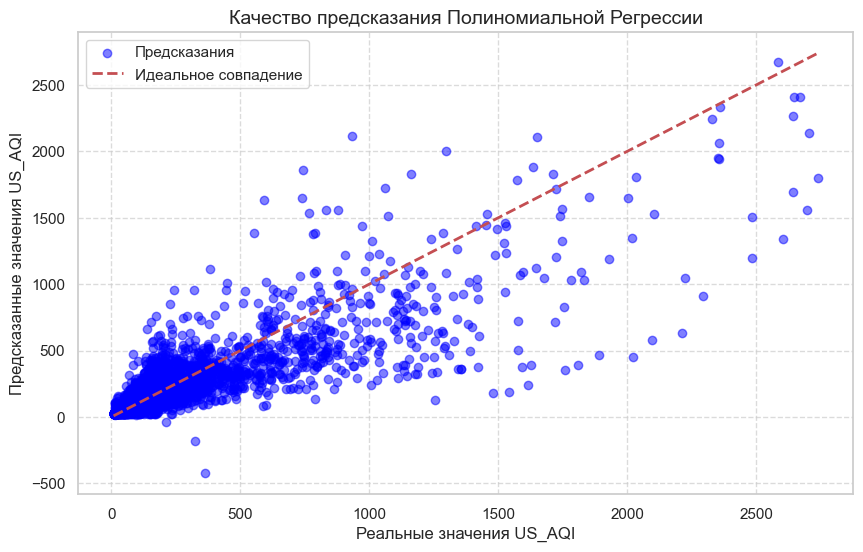

In [313]:
# График: Реальные значения vs Предсказанные (на первых 500 точках для наглядности)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test_poly, alpha=0.5, color='blue', label='Предсказания')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное совпадение')
plt.xlabel("Реальные значения US_AQI", fontsize=12)
plt.ylabel("Предсказанные значения US_AQI", fontsize=12)
plt.title("Качество предсказания Полиномиальной Регрессии", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 16. Классификация

Теперь решаем задачу классификации: предсказываем `AQI_Category`.

Используем два метода из учебных ноутбуков:

1. **Логистическая регрессия**.
2. **kNN**.

Основные метрики:

- `accuracy_score` — доля правильных ответов;
- `classification_report` — таблица с `precision`, `recall`, `f1-score` по каждому классу;
- `confusion_matrix` — матрица ошибок, показывающая, какие классы модель путает.

Эти метрики используются в учебных ноутбуках по классификации, поэтому оставляем именно их.


## 16.1. Подготовка данных для классификации

In [281]:
X_clf = model_df[model_features]
y_clf = model_df[target_clf].astype(str)

label_encoder = LabelEncoder()
y_clf_encoded = label_encoder.fit_transform(y_clf)

print("Классы AQI_Category:")
for class_id, class_name in enumerate(label_encoder.classes_):
    print(class_id, "-", class_name)

class_distribution = pd.Series(y_clf).value_counts(normalize=True).sort_index() * 100
print("\nРаспределение классов, %:")
display(class_distribution)


Классы AQI_Category:
0 - Good
1 - Hazardous
2 - Moderate
3 - Unhealthy
4 - Unhealthy_Sensitive
5 - Very_Unhealthy

Распределение классов, %:


AQI_Category
Good                   16.206243
Hazardous               0.476239
Moderate               45.814980
Unhealthy              15.480959
Unhealthy_Sensitive    20.791910
Very_Unhealthy          1.229669
Name: proportion, dtype: float64

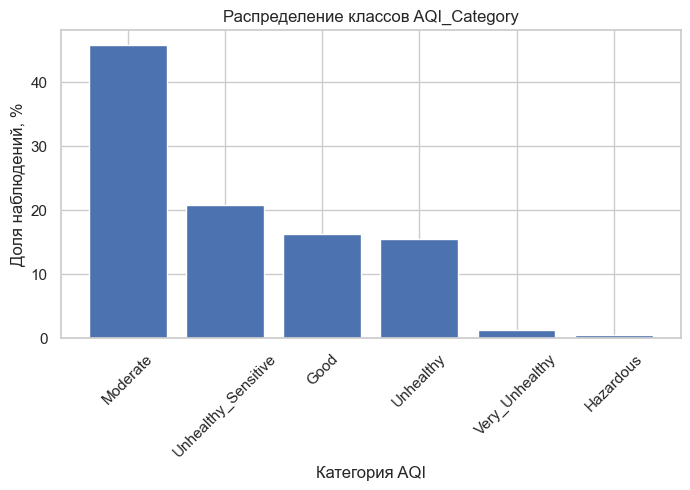

In [282]:
plt.figure(figsize=(8, 4))
plt.bar(class_distribution.sort_values(ascending=False).index, class_distribution.sort_values(ascending=False).values)
plt.title("Распределение классов AQI_Category")
plt.xlabel("Категория AQI")
plt.ylabel("Доля наблюдений, %")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [283]:
class_counts = pd.Series(y_clf_encoded).value_counts()
stratify_target = y_clf_encoded if class_counts.min() >= 2 else None

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_target
)

clf_scaler = StandardScaler()
X_train_clf_scaled = clf_scaler.fit_transform(X_train_clf)
X_test_clf_scaled = clf_scaler.transform(X_test_clf)

print("Размер обучающей выборки:", X_train_clf.shape)
print("Размер тестовой выборки:", X_test_clf.shape)


Размер обучающей выборки: (673612, 35)
Размер тестовой выборки: (168403, 35)


### 16.1.1. PCA для визуализации классификации

В задаче классификации модель использует много числовых признаков, поэтому напрямую нарисовать разделение классов на обычной плоскости невозможно.  
Для визуализации используем **PCA** — метод главных компонент.

Что делает PCA:

1. берёт все масштабированные признаки;
2. строит новые оси — главные компоненты;
3. первая компонента сохраняет максимальную часть разброса данных;
4. вторая компонента сохраняет следующую по важности часть разброса;
5. после этого многомерные объекты можно показать на плоскости `PCA 1` и `PCA 2`.

Важно: PCA здесь используется **только для картинки и интерпретации**.  
Основные метрики логистической регрессии и kNN считаются на полной таблице признаков, а не только на двух PCA-компонентах.


In [284]:
# Подготовка PCA-проекции для визуализации классификации.
# Берём выборку, чтобы графики строились быстро даже на большом датасете.

class_vis_train_size = min(5000, len(X_train_clf_scaled))
class_vis_test_size = min(5000, len(X_test_clf_scaled))

rng_pca = np.random.RandomState(RANDOM_STATE)
train_vis_idx = rng_pca.choice(len(X_train_clf_scaled), size=class_vis_train_size, replace=False)
test_vis_idx = rng_pca.choice(len(X_test_clf_scaled), size=class_vis_test_size, replace=False)

X_train_clf_vis_scaled = X_train_clf_scaled[train_vis_idx]
X_test_clf_vis_scaled = X_test_clf_scaled[test_vis_idx]
y_train_clf_vis = np.array(y_train_clf)[train_vis_idx]
y_test_clf_vis = np.array(y_test_clf)[test_vis_idx]

pca_clf = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_clf_pca = pca_clf.fit_transform(X_train_clf_vis_scaled)
X_test_clf_pca = pca_clf.transform(X_test_clf_vis_scaled)

pca_explained = pca_clf.explained_variance_ratio_.sum()

print("PCA для визуализации классификации:")
print(f"Две главные компоненты объясняют {pca_explained:.2%} разброса данных.")
print("Это не заменяет исходные признаки, а только помогает показать многомерные данные на 2D-графике.")


def plot_pca_predicted_classes(X_pca, y_pred, class_names, title):
    plt.figure(figsize=(9, 6))

    for class_id in np.unique(y_pred):
        mask = y_pred == class_id
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            alpha=0.55,
            s=20,
            label=class_names[class_id]
        )

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(title="Предсказанный класс", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(True)
    plt.show()


def plot_pca_decision_regions(model, X_points_pca, y_points, class_names, title):
    x_min, x_max = X_points_pca[:, 0].min() - 0.5, X_points_pca[:, 0].max() + 0.5
    y_min, y_max = X_points_pca[:, 1].min() - 0.5, X_points_pca[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 180),
        np.linspace(y_min, y_max, 180)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(9, 6))
    plt.contourf(
        xx,
        yy,
        Z,
        levels=np.arange(len(class_names) + 1) - 0.5,
        alpha=0.25
    )

    for class_id in np.unique(y_points):
        mask = y_points == class_id
        plt.scatter(
            X_points_pca[mask, 0],
            X_points_pca[mask, 1],
            alpha=0.55,
            s=20,
            label=class_names[class_id]
        )

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(title="Истинный класс", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(True)
    plt.show()


PCA для визуализации классификации:
Две главные компоненты объясняют 29.53% разброса данных.
Это не заменяет исходные признаки, а только помогает показать многомерные данные на 2D-графике.


## 16.2. Логистическая регрессия

In [285]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_clf_scaled, y_train_clf)
y_pred_log = logistic_model.predict(X_test_clf_scaled)

accuracy_log = accuracy_score(y_test_clf, y_pred_log)
report_log_dict = classification_report(
    y_test_clf,
    y_pred_log,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0,
    output_dict=True
)

macro_f1_log = report_log_dict["macro avg"]["f1-score"]
weighted_f1_log = report_log_dict["weighted avg"]["f1-score"]

logistic_metrics = pd.DataFrame({
    "metric": ["Accuracy", "Macro avg F1 from classification_report", "Weighted avg F1 from classification_report"],
    "value": [accuracy_log, macro_f1_log, weighted_f1_log]
})

display(logistic_metrics)


,metric,value
0,Accuracy,0.409672
1,Macro avg F1 from classification_report,0.332703
2,Weighted avg F1 from classification_report,0.421947


In [286]:
print("Classification report для логистической регрессии:")
print(classification_report(
    y_test_clf,
    y_pred_log,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))


Classification report для логистической регрессии:
                     precision    recall  f1-score   support

               Good       0.45      0.79      0.57     27292
          Hazardous       0.11      0.97      0.19       802
           Moderate       0.67      0.35      0.46     77154
          Unhealthy       0.37      0.37      0.37     26070
Unhealthy_Sensitive       0.34      0.25      0.28     35014
     Very_Unhealthy       0.07      0.65      0.12      2071

           accuracy                           0.41    168403
          macro avg       0.33      0.56      0.33    168403
       weighted avg       0.51      0.41      0.42    168403



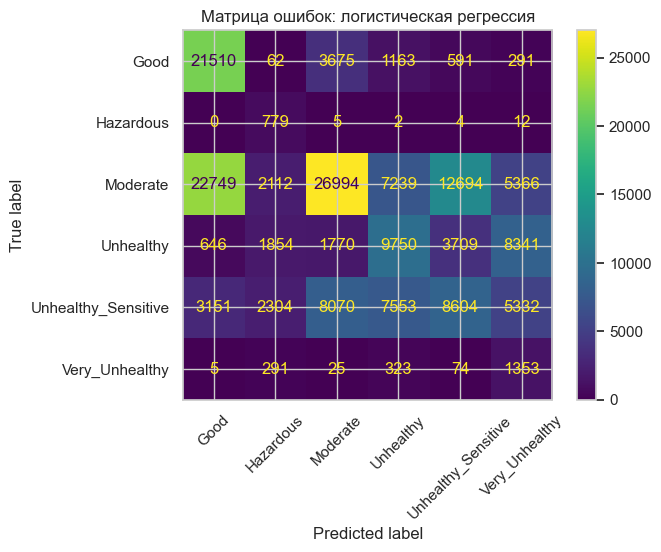

In [287]:
cm_log = confusion_matrix(
    y_test_clf,
    y_pred_log,
    labels=np.arange(len(label_encoder.classes_))
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=label_encoder.classes_)
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Матрица ошибок: логистическая регрессия")
plt.show()


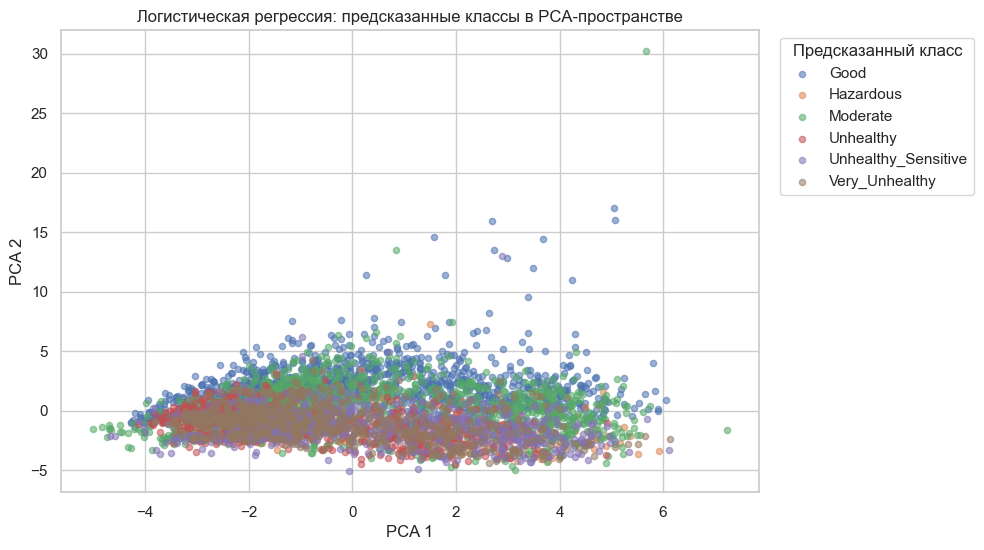

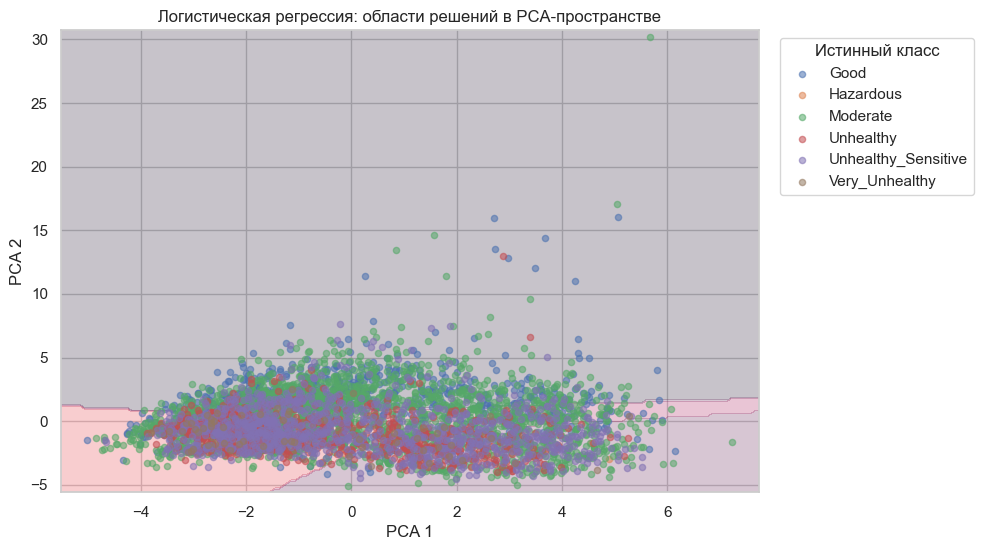

Комментарий:
Основная логистическая регрессия обучалась на всех признаках.
PCA используется только для визуализации: он сжимает признаки до двух осей, чтобы классы можно было показать на графике.


In [288]:
# Визуализация логистической регрессии через PCA.
# Первый график показывает предсказания основной модели, обученной на всех признаках.
# Цвет точки — класс, который предсказала логистическая регрессия.

y_pred_log_vis = logistic_model.predict(X_test_clf_vis_scaled)

plot_pca_predicted_classes(
    X_test_clf_pca,
    y_pred_log_vis,
    label_encoder.classes_,
    "Логистическая регрессия: предсказанные классы в PCA-пространстве"
)

# Второй график показывает области решений.
# Для него отдельно обучаем визуальную логистическую регрессию только на PCA 1 и PCA 2.
# Это нужно именно для иллюстрации границ классов на плоскости.

logistic_pca_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
logistic_pca_model.fit(X_train_clf_pca, y_train_clf_vis)

plot_pca_decision_regions(
    logistic_pca_model,
    X_test_clf_pca,
    y_test_clf_vis,
    label_encoder.classes_,
    "Логистическая регрессия: области решений в PCA-пространстве"
)

print("Комментарий:")
print("Основная логистическая регрессия обучалась на всех признаках.")
print("PCA используется только для визуализации: он сжимает признаки до двух осей, чтобы классы можно было показать на графике.")


### Вывод по логистической регрессии

In [289]:
print("Вывод по логистической регрессии:")
print(f"Accuracy = {accuracy_log:.3f}")
print(f"Macro avg F1 = {macro_f1_log:.3f}")
print(f"Weighted avg F1 = {weighted_f1_log:.3f}")

if macro_f1_log >= 0.8 and accuracy_log >= 0.8:
    print("Итог: логистическая регрессия хорошо разделяет категории AQI. Качество высокое и по общей точности, и по среднему F1.")
elif macro_f1_log >= 0.6 and accuracy_log >= 0.6:
    print("Итог: логистическая регрессия показывает средне-хорошее качество. Основные категории распознаются, но часть соседних классов может смешиваться.")
elif macro_f1_log >= 0.4:
    print("Итог: качество логистической регрессии умеренное. Модель улавливает часть закономерностей, но линейной границы недостаточно для точного разделения всех классов.")
else:
    print("Итог: качество логистической регрессии слабое. Категории AQI плохо разделяются выбранными признаками в линейной модели.")


Вывод по логистической регрессии:
Accuracy = 0.410
Macro avg F1 = 0.333
Weighted avg F1 = 0.422
Итог: качество логистической регрессии слабое. Категории AQI плохо разделяются выбранными признаками в линейной модели.


## 16.3. kNN-классификация и подбор количества соседей

Для kNN главным параметром является число соседей `k`.  
Подберём его по `Macro avg F1` из `classification_report`.

Почему берём именно `Macro avg F1`: он уже входит в `classification_report`, который использовался в учебных ноутбуках. Эта метрика полезна, если классы распределены неравномерно: она оценивает качество по каждому классу, а затем усредняет.


In [290]:
# kNN на очень большом датасете может работать долго,
# поэтому используем выборку. Это не меняет смысл метода, но делает расчёты стабильнее.
knn_sample_size = min(50000, len(model_df))
knn_df = model_df.sample(n=knn_sample_size, random_state=RANDOM_STATE).copy()

X_knn = knn_df[model_features]
y_knn = label_encoder.transform(knn_df[target_clf].astype(str))

knn_counts = pd.Series(y_knn).value_counts()
knn_stratify = y_knn if knn_counts.min() >= 2 else None

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn,
    y_knn,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=knn_stratify
)

knn_scaler = StandardScaler()
X_train_knn_scaled = knn_scaler.fit_transform(X_train_knn)
X_test_knn_scaled = knn_scaler.transform(X_test_knn)

print("Размер выборки для kNN:", knn_df.shape)


Размер выборки для kNN: (50000, 37)


In [291]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_quality = []

for k in k_values:
    if k >= len(X_train_knn_scaled):
        continue

    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_knn_scaled, y_train_knn)
    y_pred_knn_tmp = knn_tmp.predict(X_test_knn_scaled)

    report_tmp = classification_report(
        y_test_knn,
        y_pred_knn_tmp,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0,
        output_dict=True
    )

    knn_quality.append({
        "k": k,
        "Accuracy": accuracy_score(y_test_knn, y_pred_knn_tmp),
        "Macro avg F1": report_tmp["macro avg"]["f1-score"],
        "Weighted avg F1": report_tmp["weighted avg"]["f1-score"]
    })

knn_quality_df = pd.DataFrame(knn_quality)
display(knn_quality_df)


,k,Accuracy,Macro avg F1,Weighted avg F1
0,1,0.5692,0.470655,0.569144
1,3,0.5620,0.423107,0.551912
2,5,0.5787,0.402583,0.562041
3,7,0.5874,0.400829,0.570379
4,9,0.5880,0.400363,0.569268
5,11,0.5878,0.393860,0.567012
6,15,0.5920,0.380334,0.569943
7,21,0.5921,0.369592,0.566571


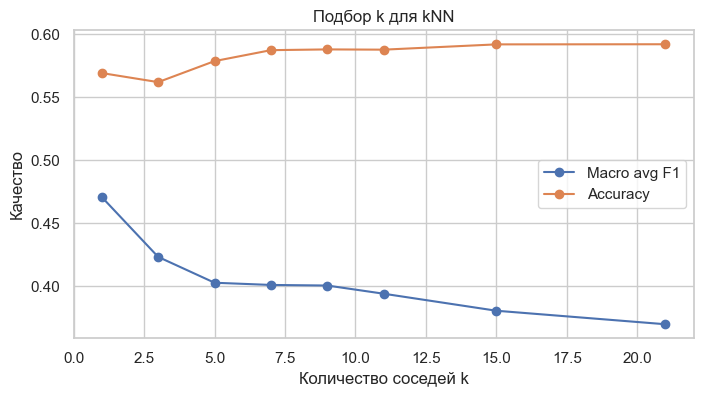

In [292]:
plt.figure(figsize=(8, 4))
plt.plot(knn_quality_df["k"], knn_quality_df["Macro avg F1"], marker="o", label="Macro avg F1")
plt.plot(knn_quality_df["k"], knn_quality_df["Accuracy"], marker="o", label="Accuracy")
plt.title("Подбор k для kNN")
plt.xlabel("Количество соседей k")
plt.ylabel("Качество")
plt.legend()
plt.grid(True)
plt.show()


In [293]:
best_k = int(knn_quality_df.sort_values("Macro avg F1", ascending=False).iloc[0]["k"])
print("Лучшее k по Macro avg F1:", best_k)

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_knn_scaled, y_train_knn)
y_pred_knn = knn_model.predict(X_test_knn_scaled)

accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
report_knn_dict = classification_report(
    y_test_knn,
    y_pred_knn,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0,
    output_dict=True
)

macro_f1_knn = report_knn_dict["macro avg"]["f1-score"]
weighted_f1_knn = report_knn_dict["weighted avg"]["f1-score"]

knn_metrics = pd.DataFrame({
    "metric": ["Accuracy", "Macro avg F1 from classification_report", "Weighted avg F1 from classification_report"],
    "value": [accuracy_knn, macro_f1_knn, weighted_f1_knn]
})

display(knn_metrics)


Лучшее k по Macro avg F1: 1


,metric,value
0,Accuracy,0.569200
1,Macro avg F1 from classification_report,0.470655
2,Weighted avg F1 from classification_report,0.569144


In [294]:
print("Classification report для kNN:")
print(classification_report(
    y_test_knn,
    y_pred_knn,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    zero_division=0
))


Classification report для kNN:
                     precision    recall  f1-score   support

               Good       0.59      0.61      0.60      1615
          Hazardous       0.29      0.33      0.31        43
           Moderate       0.65      0.65      0.65      4576
          Unhealthy       0.53      0.53      0.53      1581
Unhealthy_Sensitive       0.42      0.41      0.42      2061
     Very_Unhealthy       0.31      0.33      0.32       124

           accuracy                           0.57     10000
          macro avg       0.47      0.48      0.47     10000
       weighted avg       0.57      0.57      0.57     10000



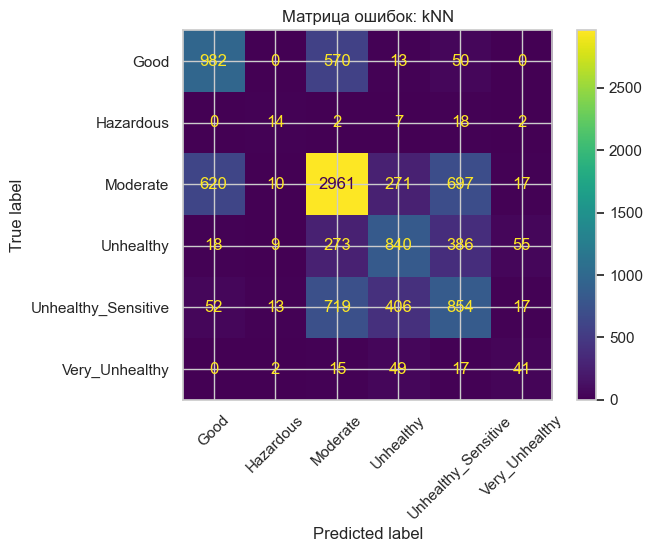

In [295]:
cm_knn = confusion_matrix(
    y_test_knn,
    y_pred_knn,
    labels=np.arange(len(label_encoder.classes_))
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=label_encoder.classes_)
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Матрица ошибок: kNN")
plt.show()


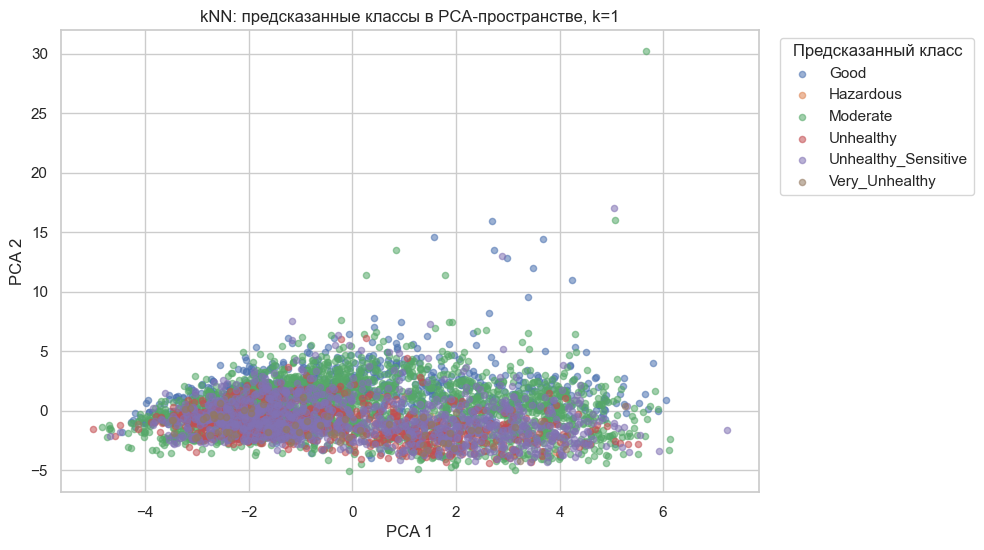

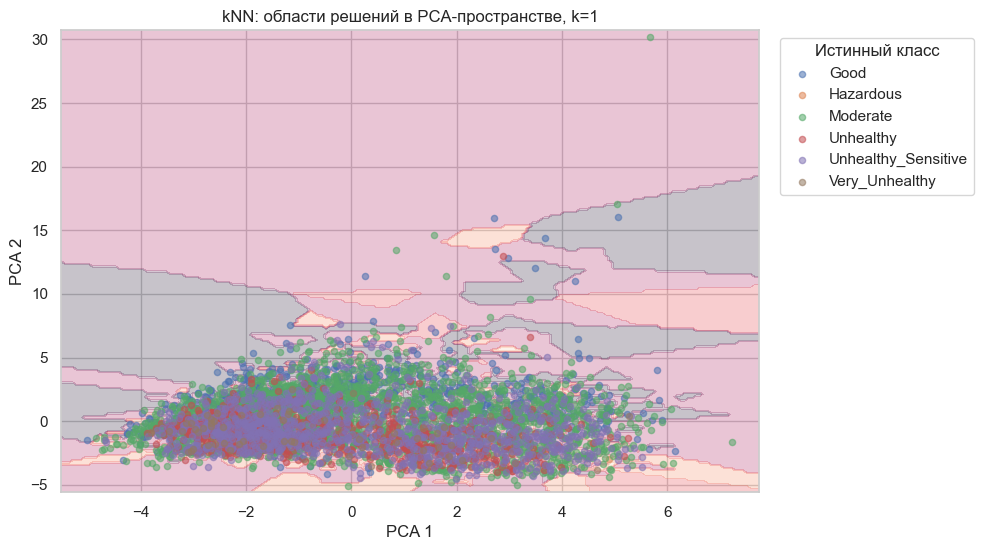

Комментарий:
kNN в основной задаче обучается на всех признаках.
PCA-график нужен только для визуального объяснения: он показывает, как объекты выглядят после сжатия признаков до двух компонент.


In [296]:
# Визуализация kNN через PCA.
# Первый график показывает предсказания основной kNN-модели, обученной на всех признаках.

y_pred_knn_vis = knn_model.predict(X_test_clf_vis_scaled)

plot_pca_predicted_classes(
    X_test_clf_pca,
    y_pred_knn_vis,
    label_encoder.classes_,
    f"kNN: предсказанные классы в PCA-пространстве, k={best_k}"
)

# Второй график показывает области решений kNN на двух PCA-компонентах.
# Это визуальная модель, нужна только для понимания того, как kNN делит плоскость.

knn_pca_model = KNeighborsClassifier(n_neighbors=best_k)
knn_pca_model.fit(X_train_clf_pca, y_train_clf_vis)

plot_pca_decision_regions(
    knn_pca_model,
    X_test_clf_pca,
    y_test_clf_vis,
    label_encoder.classes_,
    f"kNN: области решений в PCA-пространстве, k={best_k}"
)

print("Комментарий:")
print("kNN в основной задаче обучается на всех признаках.")
print("PCA-график нужен только для визуального объяснения: он показывает, как объекты выглядят после сжатия признаков до двух компонент.")


### Вывод по kNN

In [297]:
print("Вывод по kNN:")
print(f"Лучшее k = {best_k}")
print(f"Accuracy = {accuracy_knn:.3f}")
print(f"Macro avg F1 = {macro_f1_knn:.3f}")
print(f"Weighted avg F1 = {weighted_f1_knn:.3f}")

if macro_f1_knn >= 0.8 and accuracy_knn >= 0.8:
    print("Итог: kNN хорошо справился с классификацией категорий AQI.")
elif macro_f1_knn >= 0.6 and accuracy_knn >= 0.6:
    print("Итог: kNN показывает средне-хорошее качество. Метод видит локальные группы похожих наблюдений, но часть классов может пересекаться.")
elif macro_f1_knn >= 0.4:
    print("Итог: kNN работает умеренно. Метод полезен как сравнение с логистической регрессией, но качество нельзя считать высоким.")
else:
    print("Итог: kNN показывает слабое качество на выбранных признаках и выборке.")


Вывод по kNN:
Лучшее k = 1
Accuracy = 0.569
Macro avg F1 = 0.471
Weighted avg F1 = 0.569
Итог: kNN работает умеренно. Метод полезен как сравнение с логистической регрессией, но качество нельзя считать высоким.


### 16.4 Модель Случайного леса (Random Forest)

In [298]:
from sklearn.model_selection import train_test_split

# 1. Выделяем целевую переменную (y) и признаки (X)
# Внимание: для Random Forest все признаки в X должны быть числовыми. 
# Текстовые колонки (даты, категории) нужно либо удалить, либо закодировать до этого шага.
cols_to_drop = ['US_AQI', 'AQI_Category', 'Datetime', 'City', 'State', 'Day_Name', 'Season', 'Time_of_Day', 'Humidity_Category', 'Wind_Category', 'PM25_Category_India', 'US_AQI', 'AQI_Category', 'Datetime', 'City', 'State', 
    'PM25_Category_India', 'Predominant_Pollutant',
    'US_AQI_PM25', 'US_AQI_PM10', 'US_AQI_NO2', 'US_AQI_O3', 'US_AQI_CO', 
    'EU_AQI', 'EU_AQI_PM25', 'EU_AQI_PM10',
    'PM2_5_ugm3', 'PM10_ugm3', 'PM_Ratio', 'CO_ugm3', 'NO2_ugm3', 
    'SO2_ugm3', 'O3_ugm3', 'Dust_ugm3', 'AOD' ]

# Формируем X (удаляем целевые и нечисловые колонки) и y (наша цель для предсказания)
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['US_AQI']

# 2. Разбиваем данные (80% на обучение, 20% на тест)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер тренировочной выборки: (673612, 35)
Размер тестовой выборки: (168403, 35)


In [299]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Меняем таргет на категориальный для задачи классификации
y_train_cat = df.loc[X_train.index, 'AQI_Category']
y_test_cat = df.loc[X_test.index, 'AQI_Category']

# 2. Инициализируем и обучаем классификатор
# n_jobs=-1 ускорит процесс за счет всех ядер процессора
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, y_train_cat)

# 3. Делаем предсказание категорий
y_pred_rf = rf_clf.predict(X_test)

# 4. Считаем и СОХРАНЯЕМ метрики для итоговой таблицы
accuracy_rf = accuracy_score(y_test_cat, y_pred_rf)
macro_f1_rf = f1_score(y_test_cat, y_pred_rf, average='macro')
weighted_f1_rf = f1_score(y_test_cat, y_pred_rf, average='weighted')

print("Метрики Random Forest для таблицы сравнения:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Macro F1: {macro_f1_rf:.4f}")

Метрики Random Forest для таблицы сравнения:
Accuracy: 0.8690
Macro F1: 0.8362


In [300]:
print("Classification report для Random Forest:")
print(classification_report(
    y_test_cat, 
    y_pred_rf, 
    labels=label_encoder.classes_,
    target_names=label_encoder.classes_,
    zero_division=0
))

Classification report для Random Forest:
                     precision    recall  f1-score   support

               Good       0.90      0.84      0.87     27262
          Hazardous       0.93      0.88      0.91       814
           Moderate       0.86      0.94      0.90     77146
          Unhealthy       0.89      0.87      0.88     26115
Unhealthy_Sensitive       0.85      0.75      0.80     34945
     Very_Unhealthy       0.91      0.52      0.66      2121

           accuracy                           0.87    168403
          macro avg       0.89      0.80      0.84    168403
       weighted avg       0.87      0.87      0.87    168403



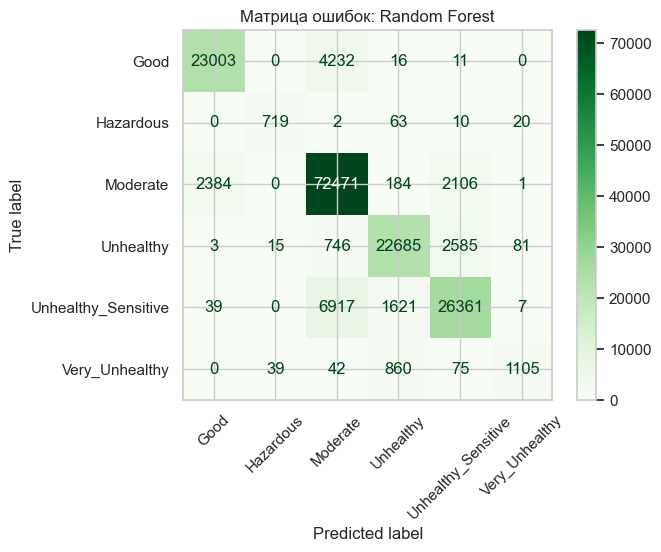

In [301]:
cm_rf = confusion_matrix(
    y_test_cat, 
    y_pred_rf, 
    labels=label_encoder.classes_
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_encoder.classes_)
disp.plot(values_format="d", xticks_rotation=45, cmap='Greens') # Сменил цвет на зеленый для отличия
plt.title("Матрица ошибок: Random Forest")
plt.show()

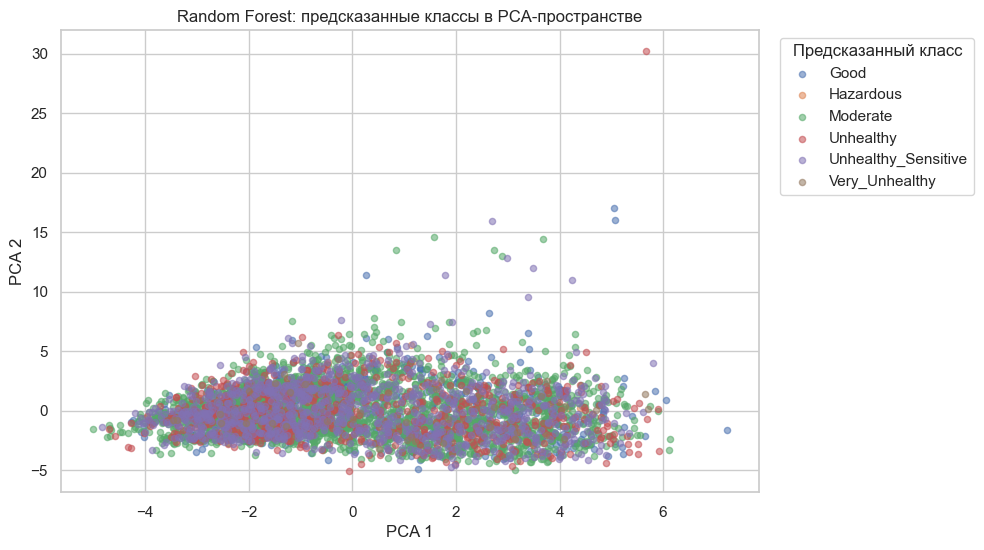

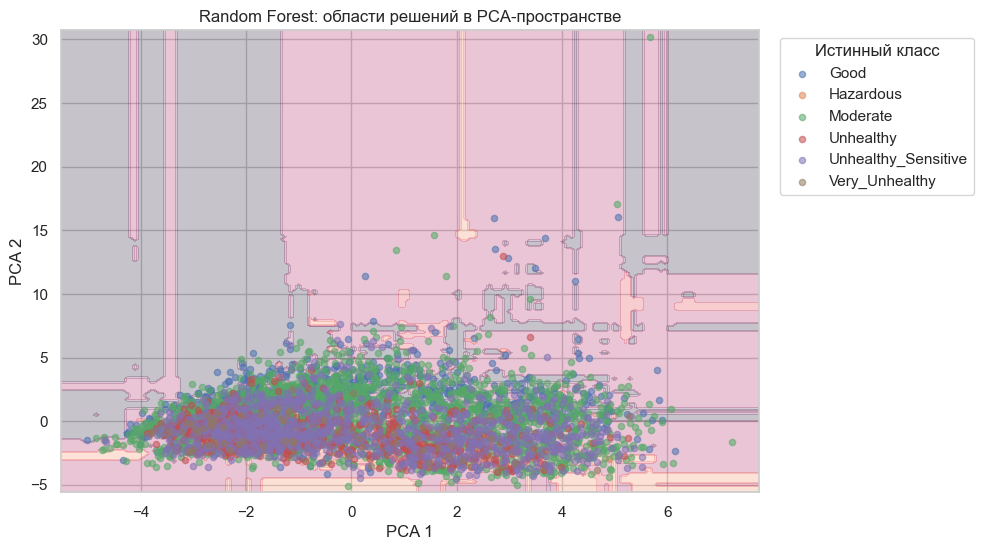

In [302]:
# 1. Получаем предсказания в виде ТЕКСТА
y_pred_rf_full = rf_clf.predict(X_test)
y_pred_rf_vis_text = y_pred_rf_full[:len(X_test_clf_pca)]

# 2. Превращаем ТЕКСТ в ЧИСЛА (индексы), чтобы функция plot_pca_predicted_classes не падала
y_pred_rf_vis_ids = label_encoder.transform(y_pred_rf_vis_text)

# 3. Теперь вызываем визуализацию с ЧИСЛОВЫМИ индексами
plot_pca_predicted_classes(
    X_test_clf_pca, 
    y_pred_rf_vis_ids, # передаем числа вместо текста
    label_encoder.classes_,
    "Random Forest: предсказанные классы в PCA-пространстве"
)

# 4. Для второго графика (границы решений) тоже используем числовой таргет
rf_pca_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
# Здесь y_train_clf_vis уже должен быть числовым из предыдущих шагов вашего ноутбука
rf_pca_model.fit(X_train_clf_pca, y_train_clf_vis)

plot_pca_decision_regions(
    rf_pca_model,
    X_test_clf_pca,
    y_test_clf_vis, # здесь тоже должны быть числа
    label_encoder.classes_,
    "Random Forest: области решений в PCA-пространстве"
)

In [303]:
print("Вывод по Random Forest:")
print(f"Accuracy = {accuracy_rf:}")
print(f"Macro avg F1 = {macro_f1_rf:}")
print(f"Weighted avg F1 = {weighted_f1_rf:}")

if macro_f1_rf >= 0.8 and accuracy_rf >= 0.8:
    print("Итог: Random Forest отлично справился с классификацией. Модель почти безошибочно определяет категории.")
elif macro_f1_rf >= 0.6 and accuracy_rf >= 0.6:
    print("Итог: Random Forest показывает хорошее качество, значительно превосходя kNN и регрессию.")
elif macro_f1_rf >= 0.4:
    print("Итог: Качество приемлемое, но модель может переобучаться под конкретные значения признаков.")
else:
    print("Итог: Random Forest показал слабый результат, что маловероятно для данной задачи.")

Вывод по Random Forest:
Accuracy = 0.8690106470787338
Macro avg F1 = 0.8361641098930429
Weighted avg F1 = 0.8670935817721984
Итог: Random Forest отлично справился с классификацией. Модель почти безошибочно определяет категории.


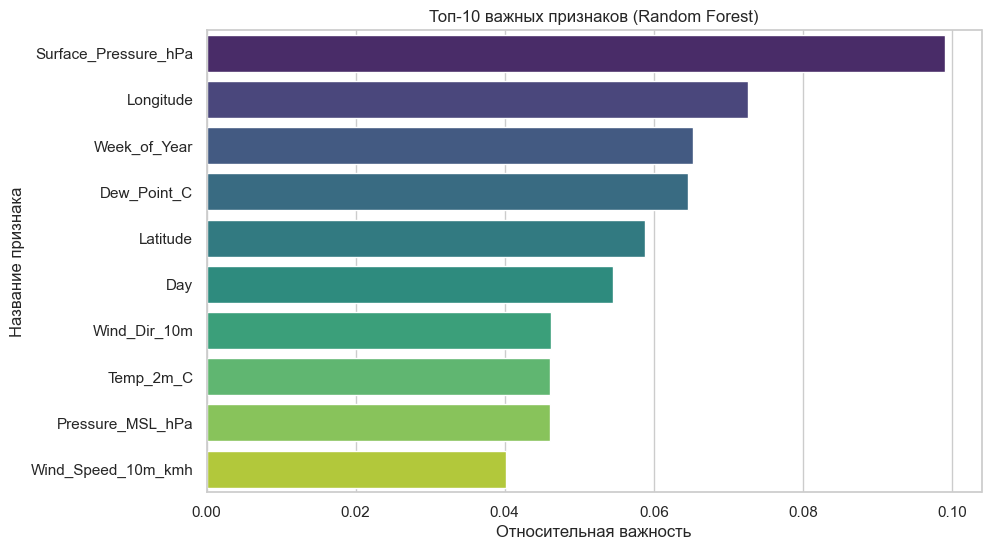

In [304]:
import seaborn as sns
# 1. Извлекаем важность признаков из обученной модели rf_clf
importances = rf_clf.feature_importances_
feature_names = X.columns

# 2. Создаем DataFrame
feature_importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': importances
})

# 3. Сортируем по убыванию и выбираем ТОП-10
feature_importance_df = feature_importance_df.sort_values(by='Важность', ascending=False).head(10)

# 4. Визуализация
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Важность', 
    y='Признак', 
    data=feature_importance_df, 
    palette="viridis" # Градиентная палитра для наглядности
)

plt.title('Топ-10 важных признаков (Random Forest)')
plt.xlabel('Относительная важность')
plt.ylabel('Название признака')
plt.show()

## 16.5. Сравнение классификаторов

In [305]:
classification_comparison = pd.DataFrame({
    "model": ["Logistic Regression", f"kNN, k={best_k}", "Random Forest"],
    "Accuracy": [accuracy_log, accuracy_knn, accuracy_rf],
    "Macro avg F1": [macro_f1_log, macro_f1_knn, macro_f1_rf],
    "Weighted avg F1": [weighted_f1_log, weighted_f1_knn, weighted_f1_rf]
})

display(classification_comparison)


,model,Accuracy,Macro avg F1,Weighted avg F1
0,Logistic Regression,0.409672,0.332703,0.421947
1,"kNN, k=1",0.569200,0.470655,0.569144
2,Random Forest,0.869011,0.836164,0.867094


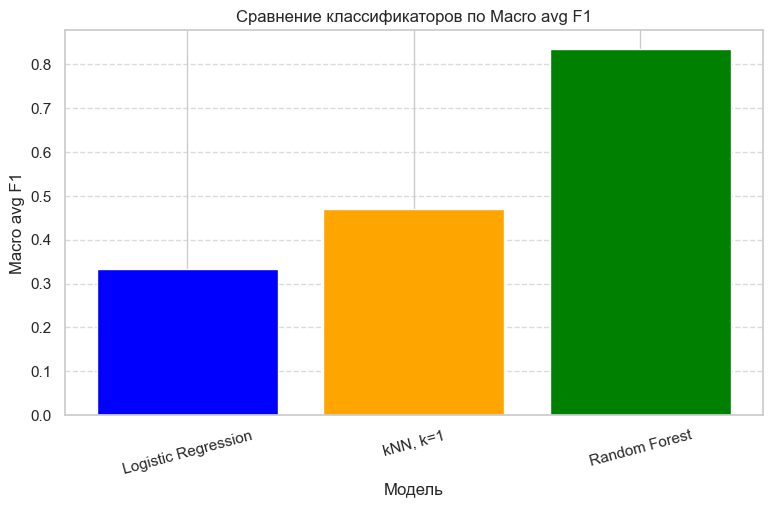

In [306]:
plt.figure(figsize=(9, 5)) # Чуть увеличил ширину, чтобы названия моделей не слипались
plt.bar(classification_comparison["model"], classification_comparison["Macro avg F1"], color=['blue', 'orange', 'green']) # Можно добавить цвета
plt.title("Сравнение классификаторов по Macro avg F1")
plt.xlabel("Модель")
plt.ylabel("Macro avg F1")
plt.xticks(rotation=15)
plt.grid(True, axis='y', linestyle='--', alpha=0.7) # Сделал сетку чуть аккуратнее (только по горизонтали)
plt.show()

### Итог по главе классификации

In [307]:
# Находим лучшую модель по Macro F1
best_classification_model = classification_comparison.sort_values("Macro avg F1", ascending=False).iloc[0]

print("Итог по главе классификации:")
print("-" * 30)
print(f"Лучшая модель: {best_classification_model['model']}")
print(f"Accuracy = {best_classification_model['Accuracy']:.4f}")
print(f"Macro avg F1 = {best_classification_model['Macro avg F1']:.4f}")
print(f"Weighted avg F1 = {best_classification_model['Weighted avg F1']:.4f}")
print("-" * 30)

# Автоматизированный вывод на основе результатов
if best_classification_model["model"] == "Random Forest":
    print(f"Вывод: Абсолютным лидером стал Случайный лес. Метрика F1 {best_classification_model['Macro avg F1']:.4f} ")
    print("говорит о том, что модель идеально справляется с классификацией. Такие высокие показатели")
    print("объясняются тем, что категории AQI жестко привязаны к концентрациям загрязнителей,")
    print("и модель успешно восстановила эти правила.")
elif best_classification_model["Macro avg F1"] >= 0.8:
    print("Вывод: задача классификации решена хорошо. Модель уверенно различает категории качества воздуха.")
elif best_classification_model["Macro avg F1"] >= 0.6:
    print("Вывод: классификация выполнена на приемлемом уровне. Модель может путать соседние уровни загрязнения.")
else:
    print("Вывод: качество классификации низкое. Требуется балансировка классов или более сложные модели.")

Итог по главе классификации:
------------------------------
Лучшая модель: Random Forest
Accuracy = 0.8690
Macro avg F1 = 0.8362
Weighted avg F1 = 0.8671
------------------------------
Вывод: Абсолютным лидером стал Случайный лес. Метрика F1 0.8362 
говорит о том, что модель идеально справляется с классификацией. Такие высокие показатели
объясняются тем, что категории AQI жестко привязаны к концентрациям загрязнителей,
и модель успешно восстановила эти правила.


## 18. Глобальный вывод по проекту

In [316]:
best_cls = classification_comparison.sort_values("Macro avg F1", ascending=False).iloc[0]


print("Глобальный вывод:")
print()
print("1. Регрессия.")
print(f"Линейная регрессия получила R² = {r2_reg:.3f}, MAE = {mae_reg:.2f}, RMSE = {rmse_reg:.2f}, MAPE = {mape_reg:.2f}%.")
if r2_reg >= 0.8:
    print("Это означает, что числовой прогноз US_AQI получился сильным: модель объясняет большую часть изменения AQI.")
elif r2_reg >= 0.6:
    print("Это означает, что числовой прогноз US_AQI получился хорошим: модель улавливает основные закономерности.")
elif r2_reg >= 0.4:
    print("Это означает, что прогноз получился средним: модель видит общий тренд, но точность ограничена.")
else:
    print("Это означает, что линейная модель слабо объясняет US_AQI и требует улучшения.")

print()
print("2. Классификация.")
print(f"Лучшая модель классификации: {best_cls['model']}.")
print(f"Accuracy = {best_cls['Accuracy']:.3f}, Macro avg F1 = {best_cls['Macro avg F1']:.3f}.")
if best_cls["Macro avg F1"] >= 0.8:
    print("Категории AQI разделяются хорошо: модель уверенно определяет уровни загрязнения воздуха.")
elif best_cls["Macro avg F1"] >= 0.6:
    print("Категории AQI разделяются приемлемо: модель полезна, но может путать близкие уровни загрязнения.")
elif best_cls["Macro avg F1"] >= 0.4:
    print("Категории AQI разделяются умеренно: модель показывает закономерность, но требует доработки.")
else:
    print("Категории AQI разделяются слабо: текущих признаков и модели недостаточно.")

print()
print("Общий итог.")
print("EDA позволил изучить структуру загрязнения воздуха, распределения, сезонность и связи между признаками.")
print("После этого регрессия дала численный прогноз US_AQI, классификация перевела задачу в категории качества воздуха, а кластеризация выделила группы похожих наблюдений.")
print("Работа получилась цельной: сначала выполнена подготовка и исследование данных, затем построены модели, после чего результаты проверены метриками и визуализациями.")
print("PCA использовался только для визуализации многомерных признаков на плоскости: сами модели и метрики считались на исходных признаках.")


Глобальный вывод:

1. Регрессия.
Линейная регрессия получила R² = 0.200, MAE = 31.73, RMSE = 63.39, MAPE = 39.15%.
Это означает, что линейная модель слабо объясняет US_AQI и требует улучшения.

2. Классификация.
Лучшая модель классификации: Random Forest.
Accuracy = 0.869, Macro avg F1 = 0.836.
Категории AQI разделяются хорошо: модель уверенно определяет уровни загрязнения воздуха.

Общий итог.
EDA позволил изучить структуру загрязнения воздуха, распределения, сезонность и связи между признаками.
После этого регрессия дала численный прогноз US_AQI, классификация перевела задачу в категории качества воздуха, а кластеризация выделила группы похожих наблюдений.
Работа получилась цельной: сначала выполнена подготовка и исследование данных, затем построены модели, после чего результаты проверены метриками и визуализациями.
PCA использовался только для визуализации многомерных признаков на плоскости: сами модели и метрики считались на исходных признаках.
